In [1]:
import numpy as np
from farm.plant import Plant
from farm import Climate
from farm import Soil
from farm import Crop
from farm import CropModel
from farm.functions import evolved_calc_yield, plot_lin_regression
import pandas as pd
from pandas import DataFrame
from numpy import zeros
import matplotlib.pyplot as plt

/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
# ── Publication style defaults ──────────────────────────────────────────────
# Run this cell before any figure cell.
# Sets global rcParams (font sizes, legend, savefig DPI) and two helpers:
#   pub_label(ax, "(a)") — bold panel label at top-left
#   despine(ax)          — remove top and right spines
import matplotlib as mpl
import os; os.makedirs("output", exist_ok=True)

mpl.rcParams.update({
    "font.size":       10,
    "axes.labelsize":  11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon":  False,
    "savefig.dpi":     300,
    "savefig.bbox":    "tight",
})

def pub_label(ax, label, x=-0.08, y=1.02):
    """Bold panel label — (a), (b), … — at top-left of an axes."""
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=12, fontweight="bold", va="bottom", ha="left")

def despine(ax):
    """Remove top and right spines (journal standard)."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

In [3]:
# Fit Y_MAX regression from Kenya Seed Co. data (yield in kg/acre vs. days-to-maturity).
# Passing m and b explicitly avoids the internal /1000 unit issue in evolved_calc_yield.
_yd = pd.read_csv('data/Yields/hybrid_yields_verified.csv')
_, _m_yield, _b_yield = plot_lin_regression(
    _yd.verified_days_to_maturity,
    _yd.verified_yield_kg_acre,
    'verified_days_to_maturity', 'verified_yield_kg_acre', _yd,
    positive=False
)

## Model definitions

In [4]:
class Tree(Plant):
    """
    Simple tree component for agroforestry modeling.

    canopy_cover  : fraction of plot area covered by tree canopy [0-1].
                    Scales all plot-level tree fluxes (T, shade, HR).
                    Typical parkland agroforestry: 0.10 - 0.30.
    leaf_fraction : fraction of the 180-day crop season the tree carries leaves [0-1].
                    0.0 → leafless entire crop season (Faidherbia albida style:
                          no competition, no shade during crop season; HR still
                          operates via deep roots).
                    0.1 → leafed for first ~18 days, then dormant (~1-month overlap
                          before Faidherbia sheds leaves, per Roupsard 1999).
                    1.0 → leafed entire crop season (evergreen co-season tree).
                    Outside the crop season the tree is always active (kc=1.0).
                    Ref: Roupsard et al. (1999), Bayala & Prieto (2020).
    """
    def __init__(self, kc=1.0, LAI_max=2.0, canopy_cover=0.2,
                 leaf_fraction=1.0, *args, **kwargs):
        self.kc = kc
        self.LAI_max = LAI_max
        self.canopy_cover = canopy_cover
        self.leaf_fraction = leaf_fraction
        super().__init__(*args, **kwargs)

    def calc_LAI(self):
        return self.LAI_max

    def calc_I(self, LAI=None, int_efficiency=0.5):
        LAI_use = self.LAI if LAI is None else LAI
        return LAI_use * int_efficiency

    def calc_T(self, s, LAI=None, kc=None):
        kc_use = self.kc if kc is None else kc
        if s >= self.s_star:
            return kc_use * self.T_MAX
        elif s >= self.sw:
            return (s - self.sw) / (self.s_star - self.sw) * (kc_use * self.T_MAX)
        else:
            return 0.0


In [5]:
def shade_factor(LAI_tree, k_shade=0.3):
    """
    Fraction of incoming energy available for evaporation/transpiration.

    LAI_tree : tree leaf area index
    k_shade  : shading efficiency [−]

    Returns value in (0, 1].
    """
    return np.exp(-k_shade * LAI_tree)


In [ ]:
class TreeCropModel:
    def __init__(self, soil=None, climate=None, crop=None, tree=None, hr_max=1.0):
        """
        hr_max : plot-level hydraulic redistribution capacity [mm/day].
                 NOT scaled by canopy_cover — hr_max is already a plot-level rate.
                 HR flux is proportional to the water-potential gradient (Clapp-Hornberger),
                 normalised so hr_max is the flux when s_deep ≈ s_fc and s_top ≈ crop sw.
                 Literature: 0.1-1.0 mm/night at plot scale in savanna parkland
                 (Burgess et al. 2001, Caldwell et al. 1991, Bayala & Prieto 2020).
        """
        self.soil = soil
        self.crop = crop
        self.tree = tree
        self.climate = climate
        self.hr_max = hr_max

        self.nZr_top = soil.set_nZr(self.crop)

        class _Tmp: pass
        tmp = _Tmp()
        tmp.Zr = max(self.tree.Zr - self.crop.Zr, 0.0)
        self.nZr_deep_full = soil.set_nZr(tmp) if tmp.Zr > 0 else 0.0

        # Reference Δψ for HR normalisation [MPa]:
        # ψ at field capacity (deep, well-watered) minus ψ at crop wilting point (top, dry).
        # Ensures hr_max [mm/day] is the flux when s_deep ≈ s_fc and s_top ≈ crop sw.
        psi_fc = soil.Psi_S_MPa * soil.sfc ** (-soil.b)
        psi_sw = soil.Psi_S_MPa * self.crop.sw ** (-soil.b)
        self._delta_psi_ref = abs(psi_sw - psi_fc)  # MPa > 0

    def _calc_L(self, s0, nZr):
        """Laio (2001) gravity drainage for a soil layer with given nZr [mm/day].
        Same physics as soil.calc_L() but accepts nZr directly rather than requiring
        soil.nZr to be set, so it works correctly for both the top and deep layers.
        """
        Lmax = s0 - self.soil.sfc
        if Lmax > 0 and nZr > 0:
            beta = 2 * self.soil.b + 4
            m = self.soil.Ks / (nZr * (np.exp(beta * (1 - self.soil.sfc)) - 1))
            L = (1 / beta) * np.log(
                np.exp(beta * (s0 - self.soil.sfc))
                - np.exp(-m * beta) * (np.exp(beta * (s0 - self.soil.sfc)) - 1))
            return min(L, Lmax) * nZr
        return 0.0

    def pre_allocate(self):
        n = self.n_days
        self.R          = zeros(n)
        self.s_top      = zeros(n + 1)
        self.s_deep     = zeros(n + 1)
        self.ET         = zeros(n)
        self.I          = zeros(n)
        self.E          = zeros(n)
        self.T          = zeros(n)
        self.L          = zeros(n)
        self.Q          = zeros(n)
        self.HR         = zeros(n)   # hydraulic redistribution flux [mm/day]
        self.kc_tree    = zeros(n)   # effective tree kc (0 when dormant, i.e. past leaf_fraction×lgp days)
        self.dos        = zeros(n)
        self.dsdt       = zeros(n)
        self.LAI        = zeros(n)
        self.kc         = zeros(n)
        self.stress     = zeros(n)
        self.T_tree     = zeros(n)
        self.ET_crop    = zeros(n)
        self.ET_tree    = zeros(n)
        self.T_tree_top = zeros(n)
        self.T_tree_deep= zeros(n)

    def run(self, do_output=False, s0=0.3, planting_date=100,
            t_before=60, t_after=7,
            deep_roots=True, shade_on=True, hr_on=True, ci_on=True,
            s_deep_0=None):
        """
        deep_roots : trees access the deep layer (default True)
        shade_on   : tree canopy shades soil evaporation E (default True).
                     Shade is NOT applied to T_crop — transpiration is VPD-driven
                     and partial shade does not proportionally reduce T.
        hr_on      : hydraulic redistribution active (default True).
                     Trees passively lift water from deep to top when s_deep > s_top.
        ci_on      : tree canopy interception active (default True).
                     When False, only crop interception is computed.
        """
        self.planting_date = planting_date
        self.n_days = t_before + self.crop.lgp + t_after
        self.pre_allocate()
        self.nZr_deep = self.nZr_deep_full if deep_roots else 0.0

        self.doy_start = self.planting_date - t_before
        if self.doy_start <= 0:
            self.doy_start = 365 + self.doy_start

        doy = np.arange(self.doy_start, self.doy_start + self.n_days)
        while (doy - 365 > 0).any():
            doy = doy - 365 * ((doy - 365) > 0)

        for t in range(self.n_days):
            self.R[t] = self.climate.rainfall[doy[t] - 1]
        self.doy = doy

        # Top layer: standard pre-season soil moisture (same as CropModel default).
        # Deep layer: field capacity — represents water accumulated by pre-season rains
        # at depth, where direct evaporation cannot reach. This is the physical reservoir
        # that makes hydraulic redistribution possible in semi-arid parkland agroforestry.
        self.s_top[0]  = s0
        self.s_deep[0] = s_deep_0 if s_deep_0 is not None else self.soil.sfc
        dos = 0
        planted = False

        for t in range(self.n_days):
            if self.doy[t] == self.planting_date:
                planted = True
            if planted:
                dos += 1

            self.dos[t] = dos
            self.kc[t]  = self.crop.calc_kc(dos)
            self.LAI[t] = self.crop.calc_LAI(self.kc[t])
            self.stress[t] = self.crop.calc_stress(self.s_top[t])  # beginning-of-day, matches CropModel

            # --- Tree phenology: kc and LAI for this timestep
            # leaf_fraction controls what fraction of the crop season the tree carries leaves.
            # 0.0 → dormant entire crop season (Faidherbia albida style).
            # 1.0 → leafed entire crop season (evergreen co-season tree).
            # Outside the crop season the tree is always active (kc=1.0).
            in_crop_season = planted and 0 < dos <= self.crop.lgp
            leaf_day_limit = self.tree.leaf_fraction * self.crop.lgp
            if in_crop_season and dos > leaf_day_limit:
                tree_kc  = 0.0   # dormant: past leaf-carrying window this season
                tree_LAI = 0.0
            else:
                tree_kc  = self.tree.kc
                tree_LAI = self.tree.calc_LAI()
            self.kc_tree[t] = tree_kc

            self.Q[t] = self.soil.calc_Q(self.s_top[t], units="mm/day")

            # --- Interception: crop + tree canopy (Fix 5)
            # Tree interception is scaled by canopy_cover (plot-level fraction).
            # For leaf_fraction=0.0, tree_LAI=0 during crop season → no tree interception.
            # ci_on=False isolates tree interception as a mechanism (for experiments).
            I_crop = self.crop.calc_I(self.LAI[t])
            I_tree = self.tree.calc_I(LAI=tree_LAI) * self.tree.canopy_cover if ci_on else 0.0
            self.I[t] = min(I_crop + I_tree, self.R[t])
            rainfall  = max(self.R[t] - self.I[t], 0.0)

            s_top  = self.s_top[t]
            s_deep = self.s_deep[t]

            # --- Rainfall input to top layer
            s_top += (rainfall - self.Q[t]) / self.nZr_top

            # --- Top-layer drainage (Fix 3 extended)
            # Same Laio (2001) physics as the published CropModel single-layer drainage.
            # Routes to deep layer if present; exits as L if nZr_deep=0 (deep_roots=False).
            # This ensures monoculture equivalence: TreeCropModel with a ghost tree
            # (deep_roots=False, T_MAX=0, canopy_cover=0) matches CropModel exactly.
            if s_top > self.soil.sfc:
                perc_mm = self._calc_L(s_top, self.nZr_top)
                s_top  -= perc_mm / self.nZr_top
                if self.nZr_deep > 0:
                    s_deep += perc_mm / self.nZr_deep
                else:
                    self.L[t] += perc_mm

            # --- Saturation overflow
            if s_top > 1.0:
                excess_mm = (s_top - 1.0) * self.nZr_top
                s_top = 1.0
                if self.nZr_deep > 0:
                    s_deep += excess_mm / self.nZr_deep
                else:
                    self.L[t] += excess_mm

            # --- Hydraulic redistribution: deep -> top driven by Δψ (Fix 1)
            # Flux is proportional to the Clapp-Hornberger water-potential gradient,
            # normalised by Δψ_ref (s_fc → sw) so hr_max [mm/day] is the flux at the
            # maximum agronomically relevant gradient. Operates regardless of leaf_fraction.
            # Ref: Caldwell et al. (1991), Burgess et al. (2001), Bayala & Prieto (2020)
            if hr_on and self.nZr_deep > 0 and s_deep > s_top:
                psi_top  = self.soil.Psi_S_MPa * max(s_top,  1e-6) ** (-self.soil.b)
                psi_deep = self.soil.Psi_S_MPa * max(s_deep, 1e-6) ** (-self.soil.b)
                delta_psi = max(psi_deep - psi_top, 0.0)  # MPa, positive when deep wetter
                hr_flux = min(
                    self.hr_max * delta_psi / self._delta_psi_ref,
                    s_deep * self.nZr_deep,
                    (1.0 - s_top) * self.nZr_top
                )
                s_top  += hr_flux / self.nZr_top
                s_deep -= hr_flux / self.nZr_deep
                self.HR[t] = hr_flux

            # --- Tree transpiration (scaled by canopy_cover; uses leaf_fraction-aware kc)
            T_tree_canopy_pot  = self.tree.calc_T(1.0,              kc=tree_kc) * self.tree.canopy_cover
            T_tree_top_supply  = self.tree.calc_T(max(s_top,  0.0), kc=tree_kc) * self.tree.canopy_cover
            T_tree_deep_supply = self.tree.calc_T(max(s_deep, 0.0), kc=tree_kc) * self.tree.canopy_cover
            T_tree_soil_supply = T_tree_top_supply + T_tree_deep_supply

            T_tree_total_pot = min(T_tree_canopy_pot, T_tree_soil_supply)

            # Deep-first: tree preferentially uses deep roots, falling back to
            # shallow only when deep supply is exhausted. Ecophysiologically
            # correct for Faidherbia — its taproot system evolved specifically
            # to access deep water unavailable to crops.
            T_tree_deep_pot = min(T_tree_total_pot, T_tree_deep_supply)
            T_tree_top_pot  = max(T_tree_total_pot - T_tree_deep_pot, 0.0)

            # --- Crop + soil evaporation (Fix 4: shade applied to E only, not T_crop)
            # Shade reduces soil evaporation via Beer-Lambert suppression of E_max.
            # Transpiration is VPD-driven; partial shade does not proportionally reduce T.
            s_eff = max(s_top, 0.0)
            T_crop_pot = self.crop.calc_T(s_eff, LAI=self.LAI[t])
            E_pot      = self.climate.calc_E(s_eff, LAI=self.LAI[t], sh=self.soil.sh)
            sf = shade_factor(tree_LAI * self.tree.canopy_cover) if shade_on else 1.0
            E_pot *= sf

            # --- Top-layer allocation (ration when demand > supply)
            demand_top    = T_tree_top_pot + T_crop_pot + E_pot
            available_top = s_top * self.nZr_top
            if demand_top <= available_top:
                T_tree_shallow = T_tree_top_pot
                T_crop_actual  = T_crop_pot
                E_actual       = E_pot
            else:
                scale = available_top / demand_top if demand_top > 0 else 0.0
                T_tree_shallow = T_tree_top_pot * scale
                T_crop_actual  = T_crop_pot     * scale
                E_actual       = E_pot          * scale
            s_top -= (T_tree_shallow + T_crop_actual + E_actual) / self.nZr_top

            # --- Deep-layer tree uptake (backfill if shallow was rationed)
            # If top-layer rationing reduced tree's shallow uptake, compensate from deep,
            # capped by deep moisture supply and total canopy potential.
            T_tree_deep_pot = min(T_tree_total_pot - T_tree_shallow, T_tree_deep_supply)
            T_tree_deep = 0.0
            if T_tree_deep_pot > 0 and self.nZr_deep > 0:
                T_tree_deep = min(T_tree_deep_pot, s_deep * self.nZr_deep)
                s_deep -= T_tree_deep / self.nZr_deep

            T_tree_actual = T_tree_shallow + T_tree_deep

            # --- Save fluxes
            self.T_tree[t]      = T_tree_actual
            self.T[t]           = T_crop_actual
            self.E[t]           = E_actual
            self.ET_crop[t]     = T_crop_actual + E_actual
            self.ET_tree[t]     = T_tree_actual
            self.ET[t]          = self.ET_crop[t] + self.ET_tree[t]
            self.T_tree_top[t]  = T_tree_shallow
            self.T_tree_deep[t] = T_tree_deep

            # --- Deep layer gravity drainage (Fix 2: Laio 2001, same physics as top layer)
            # Water above field capacity in the deep layer drains out of the system.
            # Without this, deep water is unrealistically permanent once it percolates.
            if self.nZr_deep > 0:
                L_deep = self._calc_L(s_deep, self.nZr_deep)
                s_deep -= L_deep / self.nZr_deep
                self.L[t] += L_deep

            # --- Deep saturation overflow
            if s_deep > 1.0:
                self.L[t] += (s_deep - 1.0) * self.nZr_deep
                s_deep = 1.0

            self.s_top[t+1]  = max(s_top,  0.0)
            self.s_deep[t+1] = max(s_deep, 0.0)
            total_now  = self.s_top[t]   * self.nZr_top + self.s_deep[t]   * self.nZr_deep
            total_next = self.s_top[t+1] * self.nZr_top + self.s_deep[t+1] * self.nZr_deep
            self.dsdt[t] = total_next - total_now

        if do_output:
            return self.output()

    def output(self):
        return DataFrame({
            "kc":         self.kc,
            "kc_tree":    self.kc_tree,
            "LAI":        self.LAI,
            "stress":     self.stress,
            "R":          self.R,
            "s_top":      self.s_top[:-1],
            "s_deep":     self.s_deep[:-1],
            "I":          self.I,
            "Q":          self.Q,
            "E":          self.E,
            "T_crop":     self.T,
            "T_tree":     self.T_tree,
            "ET_crop":    self.ET_crop,
            "ET_tree":    self.ET_tree,
            "ET":         self.ET,
            "HR":         self.HR,
            "L":          self.L,
            "dsdt":       self.dsdt,
            "dos":        self.dos,
            "doy":        self.doy,
            "T_tree_top": self.T_tree_top,
            "T_tree_deep":self.T_tree_deep,
        })


In [7]:
def run_one_season(model_cls, soil_cls, crop_cls, climate_obj, *,
                   texture="loam", lgp=180,
                   planting_date=100, t_before=60, t_after=7, s0=0.3,
                   tree_params=None):

    soil = soil_cls(texture=texture)
    crop = crop_cls(soil=soil)
    crop.lgp = lgp

    if tree_params is None:
        soil.set_nZr(crop)
        model = model_cls(crop=crop, climate=climate_obj, soil=soil)
    else:
        tree = Tree(soil=soil, **tree_params)
        model = model_cls(crop=crop, tree=tree, climate=climate_obj, soil=soil)

    model.run(s0=s0, planting_date=planting_date, t_before=t_before, t_after=t_after)
    return crop, model.output()


def season_metrics(crop, df, lgp, sf=1.0):
    s_use = df["s_top"].values if "s_top" in df.columns else df["s"].values
    y_max = evolved_calc_yield(dtm=lgp, m=_m_yield, b=_b_yield)

    # Shade yield penalty: shade only hurts on days when the crop is NOT water-stressed
    # (i.e. radiation-limited days). On stressed days the crop can't use the light anyway,
    # and shade actually helps by reducing soil evaporation.
    # Penalty = (fraction of canopy light blocked) × (fraction of crop-season days unstressed)
    if sf < 1.0:
        in_season = df["dos"].values > 0
        f_unstressed = (df["stress"].values[in_season] == 0).mean() if in_season.any() else 0.0
        y_max = y_max * (1.0 - (1.0 - sf) * f_unstressed)

    avg_stress, dyn_stress, yld = crop.calc_dstress(
        s=s_use, stress=df["stress"].values, Y_MAX=y_max
    )
    return avg_stress, dyn_stress, yld, df["R"].sum()


def _tree_sf(tree_params):
    """Crop-season shade factor for a given tree parameter dict.
    Scales by leaf_fraction (fraction of crop season the tree is leafed).
    leaf_fraction=0.0 → no shade during crop season → sf=1.0.
    leaf_fraction=1.0 → full-season shade → shade_factor(LAI_max * canopy_cover).
    """
    lf = tree_params.get("leaf_fraction", 1.0)
    if lf == 0.0:
        return 1.0   # fully dormant during crop season → no shade penalty
    return shade_factor(tree_params.get("LAI_max", 2.0) *
                        tree_params.get("canopy_cover", 0.2) * lf)


def simulate_systems(n_sims, *, lgp=180, texture="loam", seed=123,
                     tree_params=None):
    rng = np.random.default_rng(seed)
    rows_mono, rows_tree = [], []
    outputs_mono, outputs_tree = [], []

    if tree_params is None:
        tree_params = dict(
            Zr=1500,
            T_MAX=1.0,
            sw_MPa=-2.0,
            s_star_MPa=-0.1,
            kc=1.0,
            canopy_cover=0.2,
            leaf_fraction=0.0,
        )

    sf_tree = _tree_sf(tree_params)

    for i in range(n_sims):
        np.random.seed(rng.integers(0, 2**32 - 1, dtype=np.uint32).item())
        climate = Climate()

        crop_m, out_m = run_one_season(CropModel, Soil, Crop, climate,
                                       texture=texture, lgp=lgp)
        a, d, y, rf = season_metrics(crop_m, out_m, lgp)
        rows_mono.append(dict(Sim=i, AvgStress=a, DynamicStress=d, Yield=y, RF=rf))
        outputs_mono.append(out_m)

        crop_t, out_t = run_one_season(TreeCropModel, Soil, Crop, climate,
                                       texture=texture, lgp=lgp,
                                       tree_params=tree_params)
        a, d, y, rf = season_metrics(crop_t, out_t, lgp, sf=sf_tree)
        rows_tree.append(dict(Sim=i, AvgStress=a, DynamicStress=d, Yield=y, RF=rf))
        outputs_tree.append(out_t)

    return pd.DataFrame(rows_mono), pd.DataFrame(rows_tree), outputs_mono, outputs_tree


## Single-season diagnostic

In [8]:
np.random.seed(3)
climate = Climate()

# --- Monoculture
crop_m, out_m = run_one_season(
    CropModel, Soil, Crop, climate,
    texture="loam", lgp=180
)

# --- Tree–crop: evergreen deep-rooted (constant kc, shade, and competition all season)
tp_evergreen = dict(
    Zr=1500, T_MAX=4.0, sw_MPa=-2.0, s_star_MPa=-0.1,
    kc=1.0, canopy_cover=0.2, leaf_fraction=1.0,
)
crop_e, out_e = run_one_season(
    TreeCropModel, Soil, Crop, climate,
    texture="loam", lgp=180, tree_params=tp_evergreen
)

# --- Tree–crop: Faidherbia-style (leafless during entire crop season)
#     leaf_fraction=0.0: kc=0 and LAI=0 during crop season → no competition, no shade.
#     HR still operates: deep roots lift water to the crop zone.
tree_params = dict(
    Zr=1500, T_MAX=1.0, sw_MPa=-2.0, s_star_MPa=-0.1,
    kc=1.0, canopy_cover=0.2, leaf_fraction=0.0,
)
crop_t, out_t = run_one_season(
    TreeCropModel, Soil, Crop, climate,
    texture="loam", lgp=180, tree_params=tree_params
)


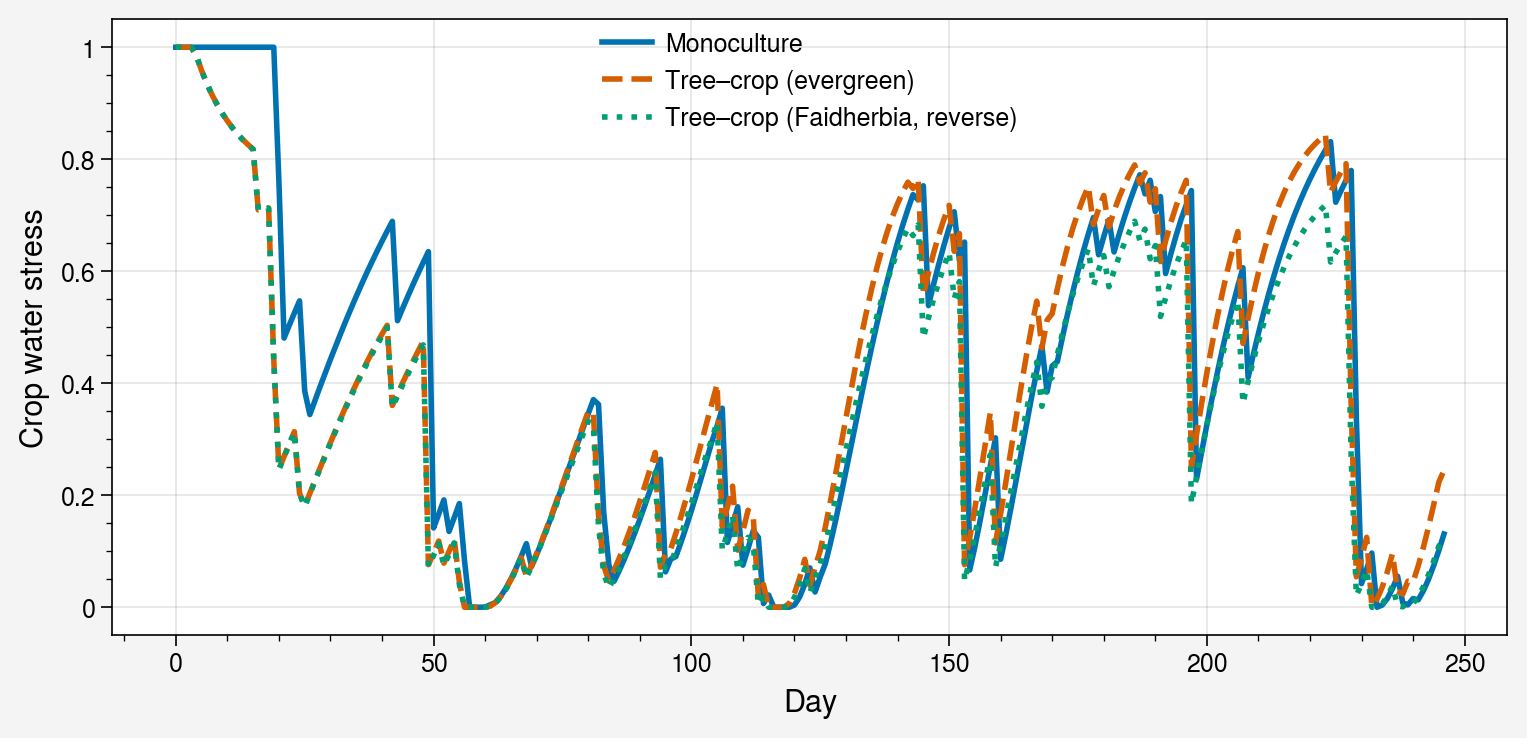

Seasonal RF: 585 mm

                        Mono   Evgrn  Faidherbia
Dyn stress             0.741   0.665       0.694
Yield (kg/ha)           1116    1445        1319
HR total (mm)              —   33.68       46.82
delta stress               —  -0.076      -0.047


In [9]:
plt.figure(figsize=(9, 4))

plt.plot(out_m["stress"], label="Monoculture", lw=2)
plt.plot(out_e["stress"], label="Tree–crop (evergreen)", lw=2, linestyle="--")
plt.plot(out_t["stress"], label="Tree–crop (Faidherbia, reverse)", lw=2, linestyle=":")

plt.xlabel("Day")
plt.ylabel("Crop water stress")
plt.legend()
plt.show()

_, d_m, y_m, rf = season_metrics(crop_m, out_m, 180)
_, d_e, y_e, _  = season_metrics(crop_e, out_e, 180)
_, d_t, y_t, _  = season_metrics(crop_t, out_t, 180)
print(f"Seasonal RF: {rf:.0f} mm\n")
print(f"{'':20s} {'Mono':>7} {'Evgrn':>7} {'Faidherbia':>11}")
print(f"{'Dyn stress':20s} {d_m:>7.3f} {d_e:>7.3f} {d_t:>11.3f}")
print(f"{'Yield (kg/ha)':20s} {y_m:>7.0f} {y_e:>7.0f} {y_t:>11.0f}")
print(f"{'HR total (mm)':20s} {'—':>7} {out_e['HR'].sum():>7.2f} {out_t['HR'].sum():>11.2f}")
print(f"{'delta stress':20s} {'—':>7} {d_e-d_m:>+7.3f} {d_t-d_m:>+11.3f}")

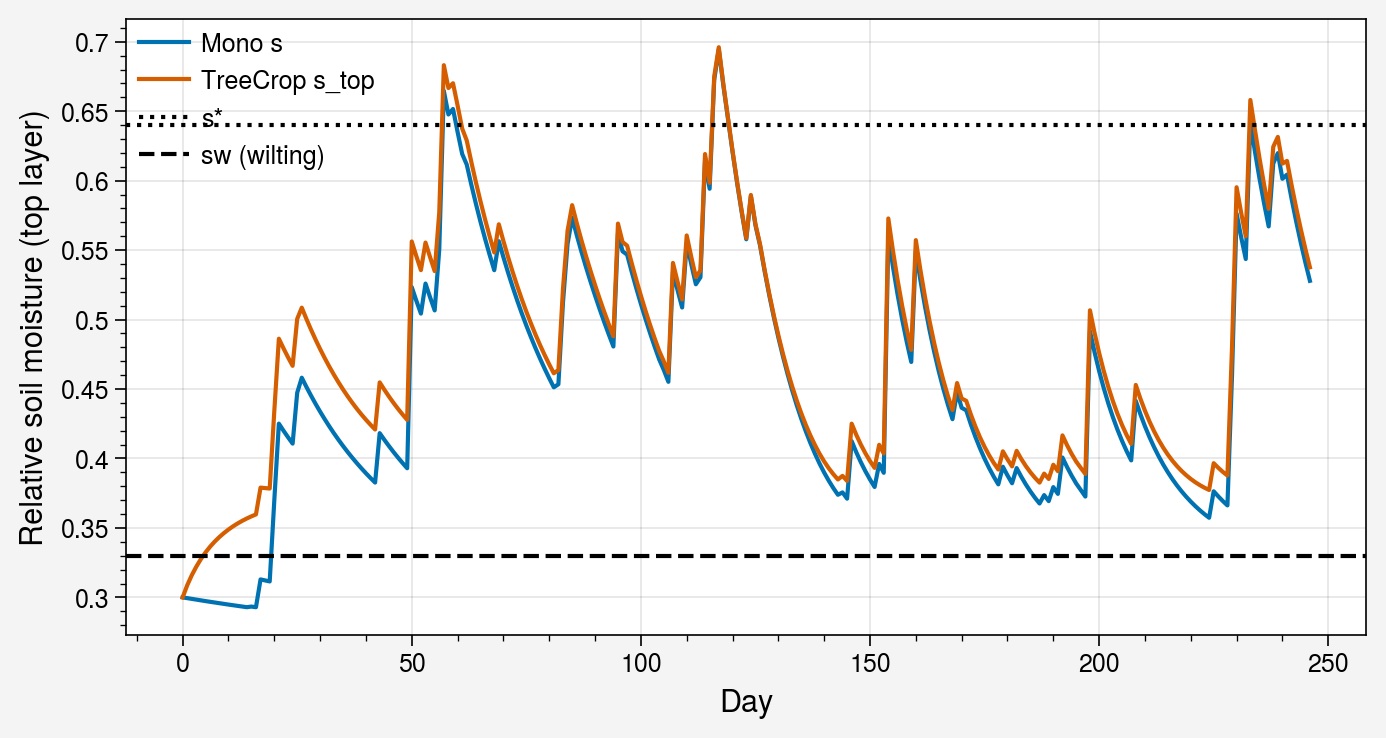

In [10]:
plt.figure(figsize=(8,4))

# Mono (single bucket)
plt.plot(out_m["s"], label="Mono s")

# Agroforestry (top layer only)
plt.plot(out_t["s_top"], label="TreeCrop s_top")

plt.axhline(crop_m.s_star, color="k", linestyle=":", label="s*")
plt.axhline(crop_m.sw, color="k", linestyle="--", label="sw (wilting)")

plt.xlabel("Day")
plt.ylabel("Relative soil moisture (top layer)")

plt.legend()
plt.show()


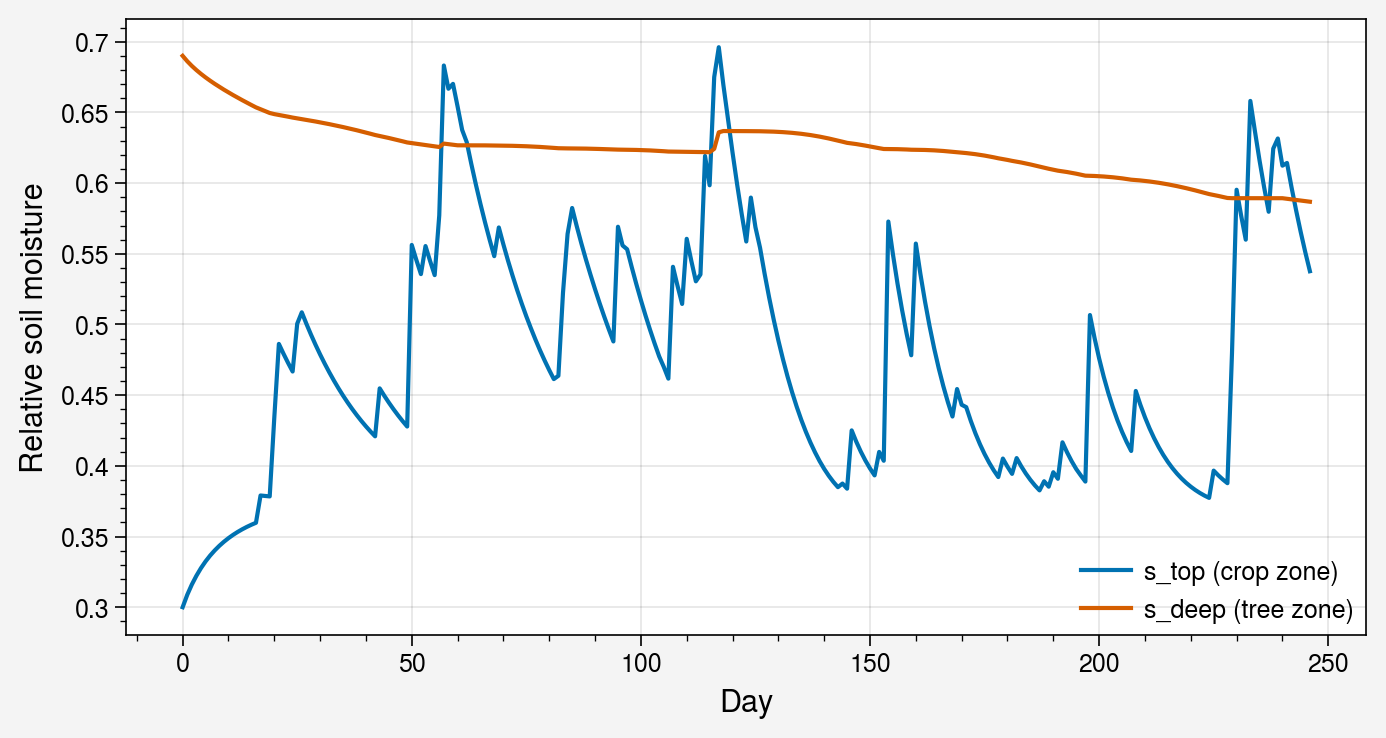

In [11]:
plt.figure(figsize=(8,4))

plt.plot(out_t["s_top"], label="s_top (crop zone)")
plt.plot(out_t["s_deep"], label="s_deep (tree zone)")

plt.xlabel("Day")
plt.ylabel("Relative soil moisture")
plt.legend()
plt.show()


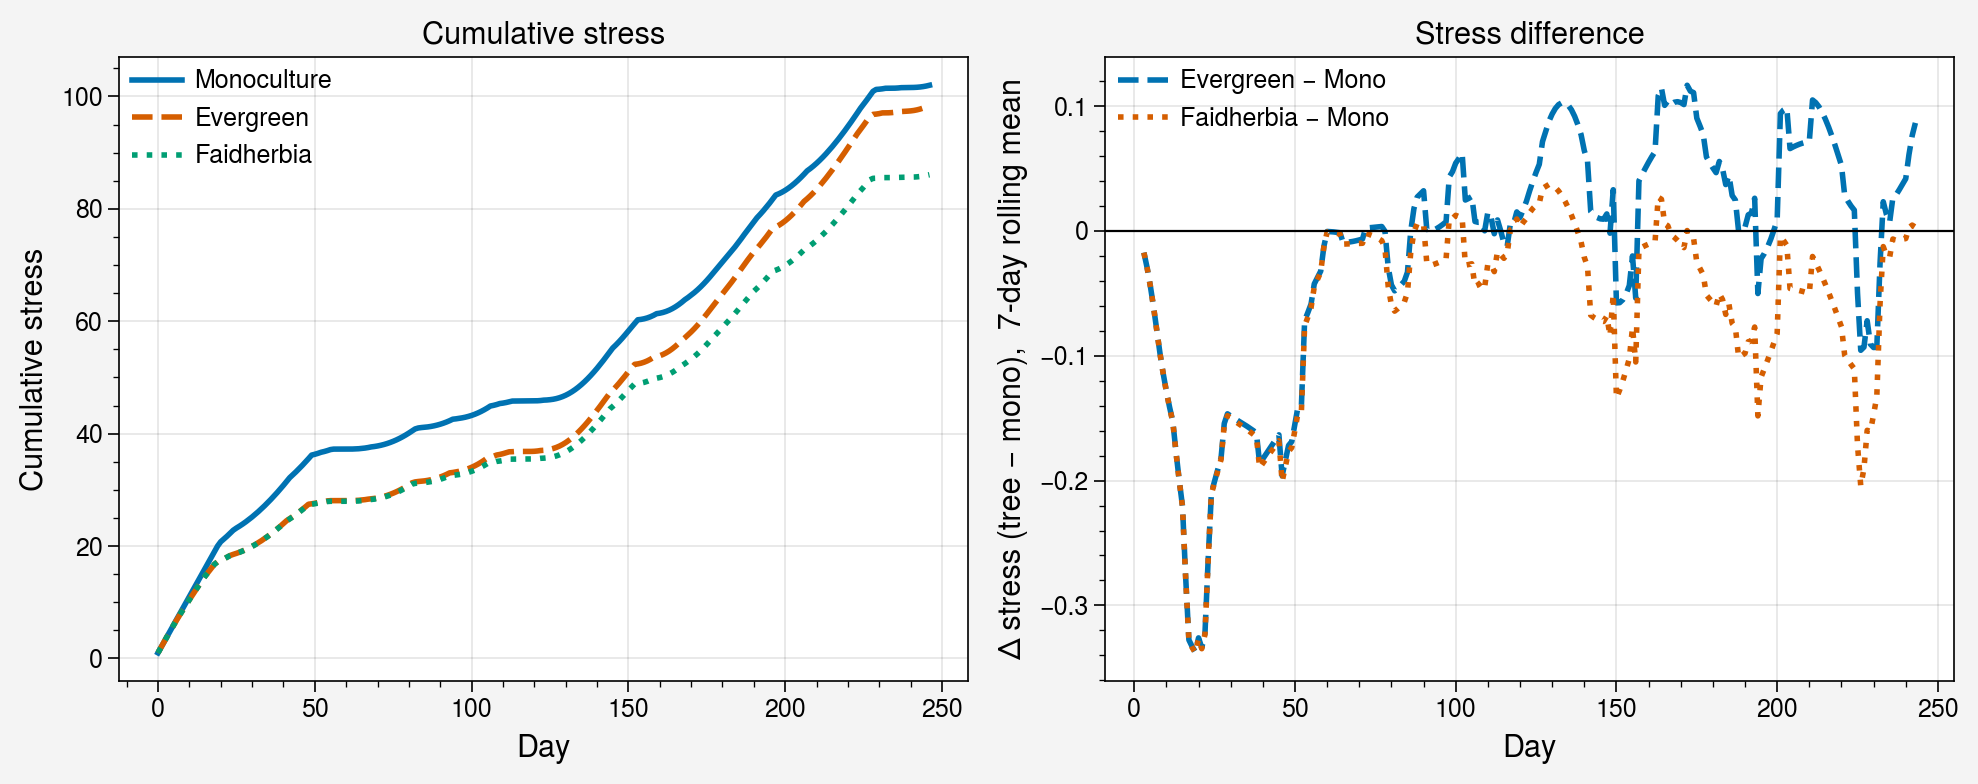

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: cumulative stress over time — divergence shows facilitation accumulating
ax = axes[0]
ax.plot(out_m["stress"].cumsum(), label="Monoculture", lw=2)
ax.plot(out_e["stress"].cumsum(), label="Evergreen", lw=2, linestyle="--")
ax.plot(out_t["stress"].cumsum(), label="Faidherbia", lw=2, linestyle=":")
ax.set_xlabel("Day")
ax.set_ylabel("Cumulative stress")
ax.legend(fontsize=9)
ax.set_title("Cumulative stress")

# Right: daily stress DELTA (TreeCrop − Mono), smoothed
ax = axes[1]
delta_e = (out_e["stress"] - out_m["stress"]).rolling(7, center=True).mean()
delta_t = (out_t["stress"] - out_m["stress"]).rolling(7, center=True).mean()
ax.plot(delta_e, label="Evergreen − Mono", lw=2, linestyle="--")
ax.plot(delta_t, label="Faidherbia − Mono", lw=2, linestyle=":")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Day")
ax.set_ylabel("Δ stress (tree − mono),  7-day rolling mean")
ax.legend(fontsize=9)
ax.set_title("Stress difference")

plt.tight_layout()
plt.show()

## Factorial experiment: deep roots × shade

In [13]:
def run_tree_scenario(deep, shade):
    model = TreeCropModel(
        soil=Soil("loam"),
        crop=Crop(soil=Soil("loam")),
        tree=Tree(soil=Soil("loam"), **tree_params),
        climate=climate
    )
    model.run(deep_roots=deep, shade_on=shade)
    return model.output()

def seasonal_dynamic_stress(out):
    return np.sum(out["stress"])

out_mono    = out_m
out_shallow = run_tree_scenario(deep=False, shade=False)
out_shade   = run_tree_scenario(deep=False, shade=True)
out_deep    = run_tree_scenario(deep=True,  shade=False)
out_full    = run_tree_scenario(deep=True,  shade=True)

baseline = seasonal_dynamic_stress(out_mono)
for name, out in [("Shallow only", out_shallow), ("Shade only",   out_shade),
                  ("Deep only",    out_deep),    ("Full system",  out_full)]:
    print(f"{name:15s}  delta = {seasonal_dynamic_stress(out) - baseline:+.1f}")


Shallow only     delta = -0.1
Shade only       delta = -1.2
Deep only        delta = -14.8
Full system      delta = -15.9


## Multi-season simulation

In [14]:
df_mono, df_tree, outs_m, outs_t = simulate_systems(
    n_sims=300,
    lgp=180,
    seed=42,
    tree_params=dict(
        Zr=1500, T_MAX=1.0, sw_MPa=-2.0, s_star_MPa=-0.1,
        kc=1.0, canopy_cover=0.2, leaf_fraction=0.0,
    ),
)

df_compare = pd.DataFrame({
    "RF": df_mono["RF"],
    "Stress_mono": df_mono["DynamicStress"],
    "Stress_tree": df_tree["DynamicStress"],
})

df_compare["delta_stress"] = (
    df_compare["Stress_tree"] - df_compare["Stress_mono"]
)

df_compare["regime"] = pd.qcut(
    df_compare["RF"],
    3,
    labels=["Dry", "Medium", "Wet"]
)

df_compare.groupby("regime", observed=False)["RF"].describe()
df_compare.groupby("regime", observed=False)["delta_stress"].mean()


regime
Dry      -0.063549
Medium   -0.041158
Wet      -0.024828
Name: delta_stress, dtype: float64

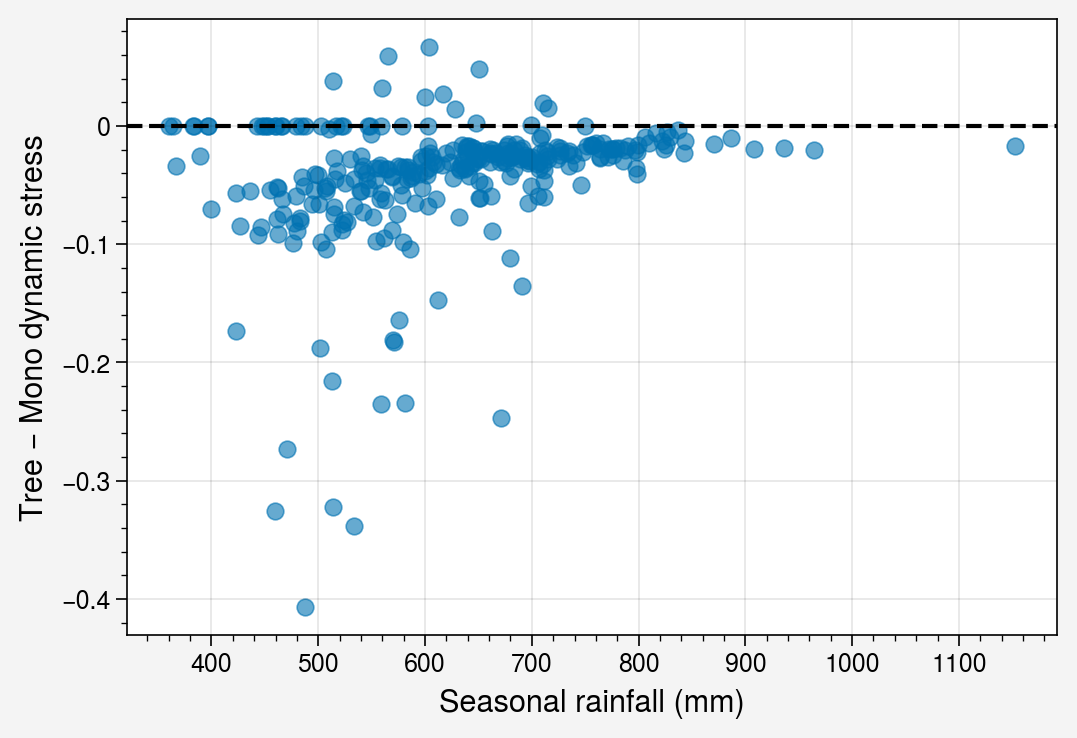

In [15]:
plt.figure(figsize=(6,4))

plt.scatter(
    df_compare["RF"],
    df_compare["delta_stress"],
    alpha=0.6
)

plt.axhline(0, linestyle="--", color="k")

plt.xlabel("Seasonal rainfall (mm)")
plt.ylabel("Tree − Mono dynamic stress")

plt.show()


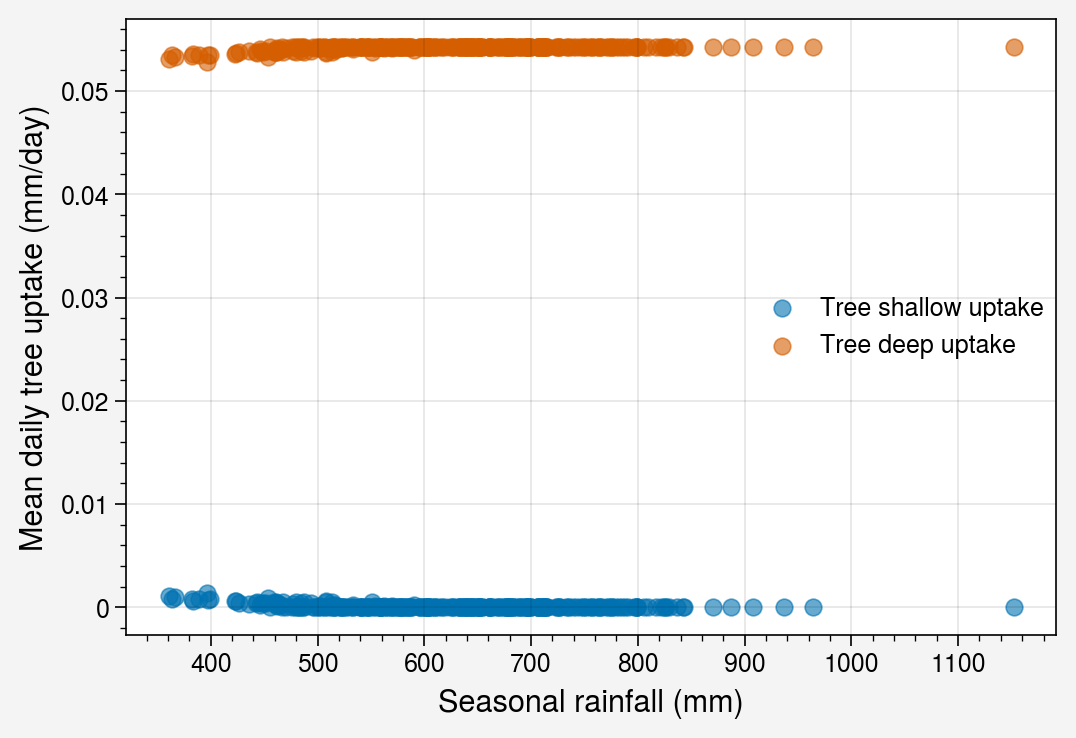

In [16]:
mean_top = []
mean_deep = []

for out in outs_t:
    mean_top.append(out["T_tree_top"].mean())
    mean_deep.append(out["T_tree_deep"].mean())

mean_top = np.array(mean_top)
mean_deep = np.array(mean_deep)
RF = df_tree["RF"].values

plt.figure(figsize=(6,4))
plt.scatter(RF, mean_top, alpha=0.6, label="Tree shallow uptake")
plt.scatter(RF, mean_deep, alpha=0.6, label="Tree deep uptake")
plt.xlabel("Seasonal rainfall (mm)")
plt.ylabel("Mean daily tree uptake (mm/day)")
plt.legend()
plt.show()


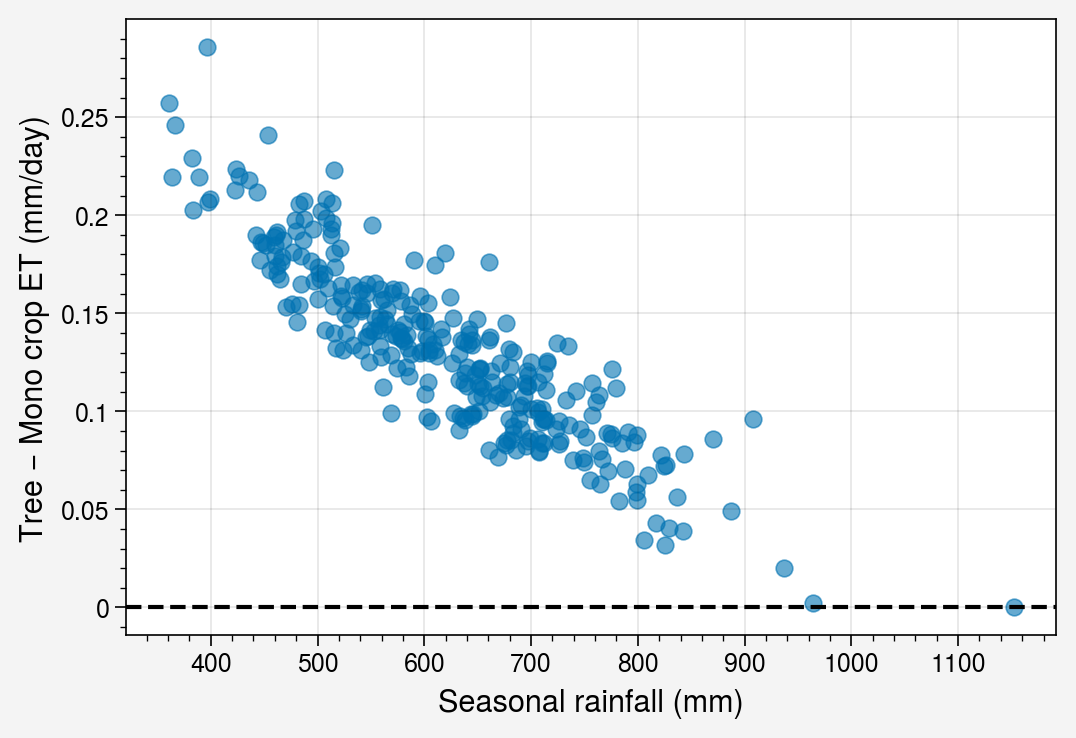

In [17]:
mean_ET_crop_tree = np.array([out["ET_crop"].mean() for out in outs_t])
mean_ET_crop_mono = np.array([out["ET"].mean() for out in outs_m])

delta_ET_crop = mean_ET_crop_tree - mean_ET_crop_mono
plt.figure(figsize=(6,4))
plt.scatter(RF, delta_ET_crop, alpha=0.6)
plt.axhline(0, linestyle="--", color="k")
plt.xlabel("Seasonal rainfall (mm)")
plt.ylabel("Tree − Mono crop ET (mm/day)")
plt.show()


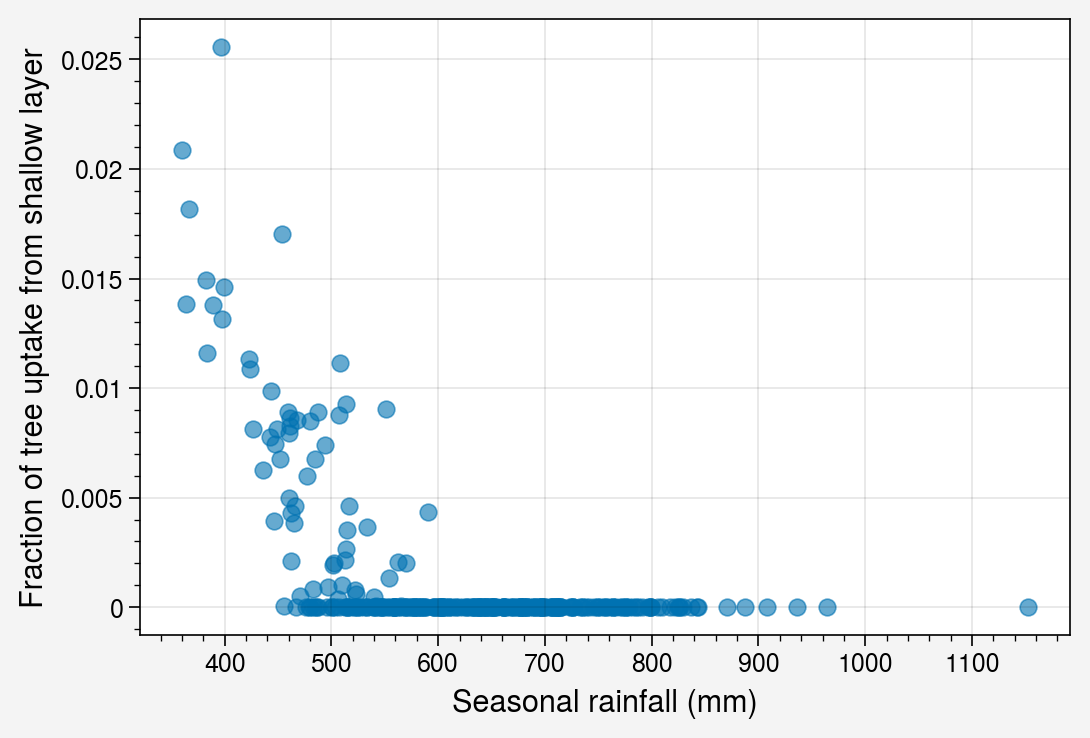

In [18]:
frac_shallow = mean_top / (mean_top + mean_deep + 1e-9)
plt.figure(figsize=(6,4))
plt.scatter(RF, frac_shallow, alpha=0.6)
plt.xlabel("Seasonal rainfall (mm)")
plt.ylabel("Fraction of tree uptake from shallow layer")
plt.show()


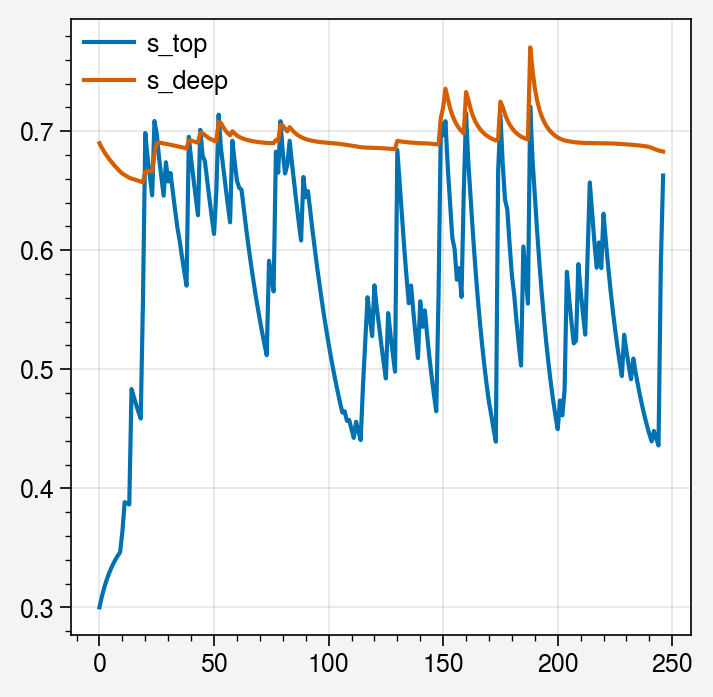

In [19]:
wet_index = np.argmax(RF)
out = outs_t[wet_index]

plt.plot(out["s_top"], label="s_top")
plt.plot(out["s_deep"], label="s_deep")
plt.legend()
plt.show()


## Rainfall regime study

| Regime | Expected pattern |
|--------|------------------|
| Few intense | frac\_shallow ≈ 1, deep ≈ 0 |
| Baseline | some deep activation |
| Many small | frac\_shallow ↓, deep ↑ |

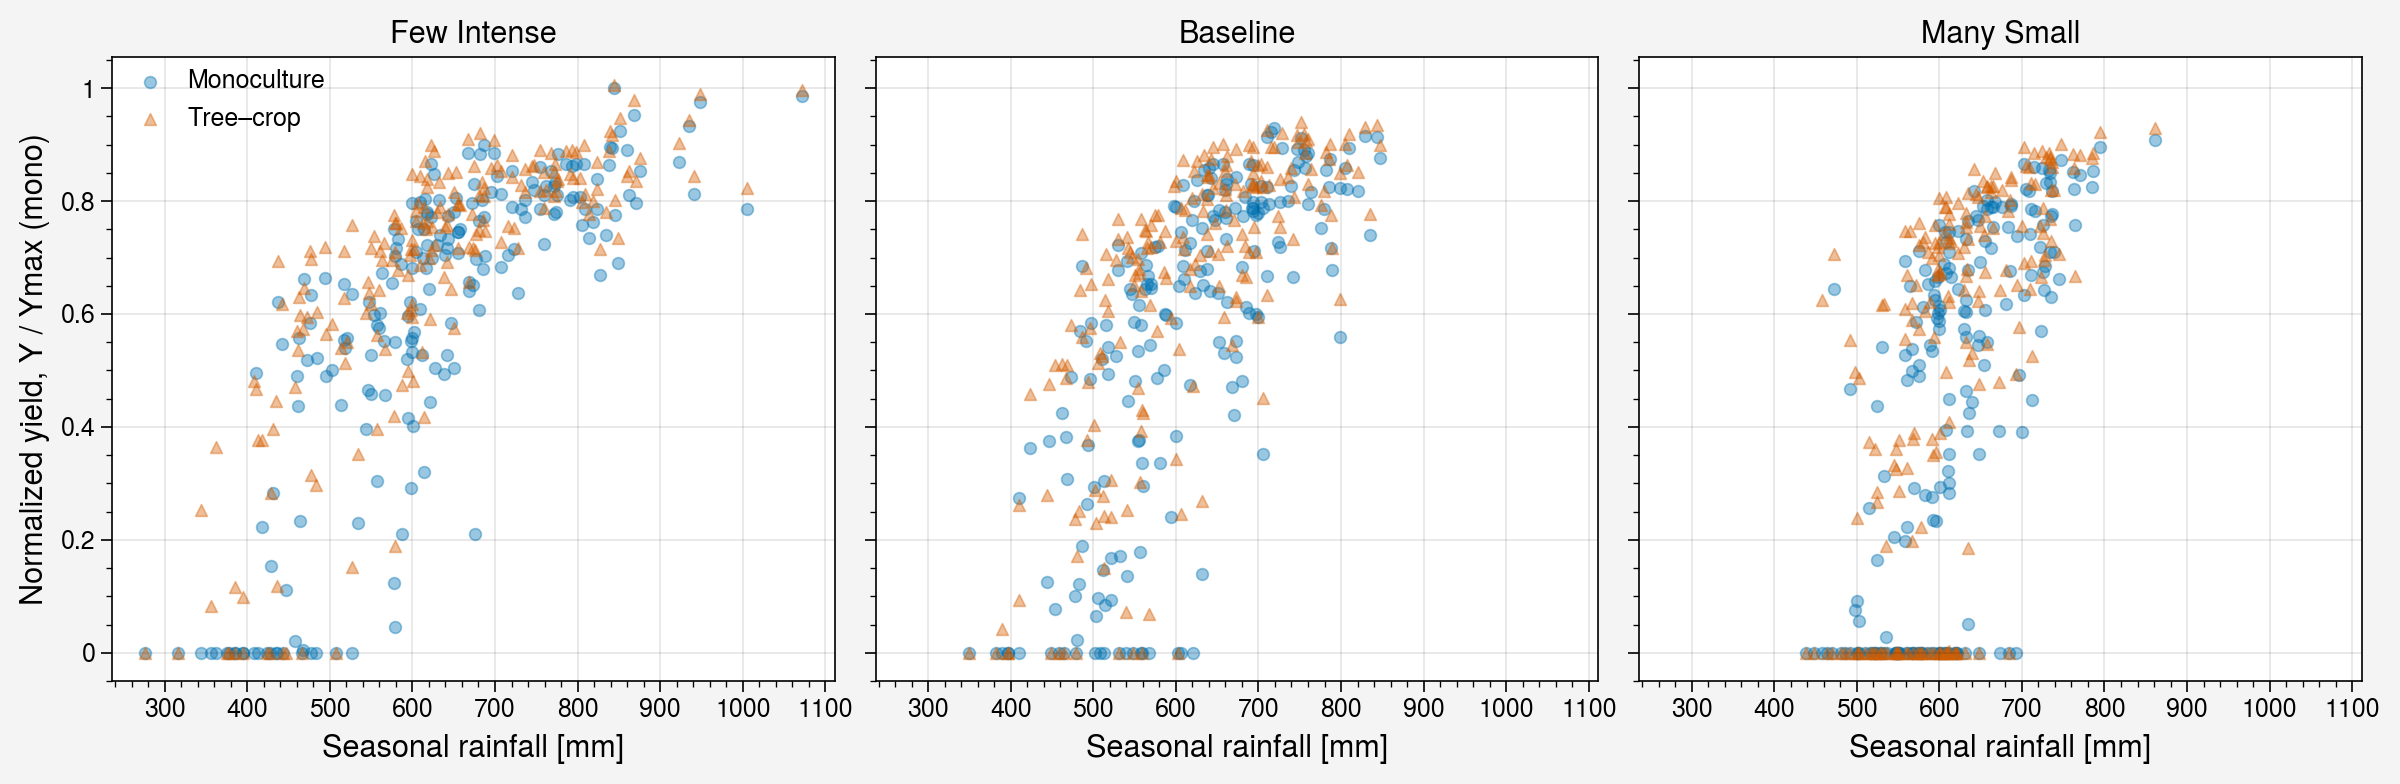

In [20]:
rain_regimes = {
    "few_intense": dict(alpha_scale=1.5, lambda_scale=0.67),
    "baseline":    dict(alpha_scale=1.0, lambda_scale=1.0),
    "many_small":  dict(alpha_scale=0.67, lambda_scale=1.5),
}

def simulate_systems_by_regime(n_sims, *, lgp=180, texture="loam", seed=123):
    rng = np.random.default_rng(seed)
    default_climate = Climate()

    rows = []

    for regime, scales in rain_regimes.items():
        for i in range(n_sims):
            np.random.seed(rng.integers(0, 2**32 - 1, dtype=np.uint32).item())

            climate = Climate(
                alpha_r=[a * scales["alpha_scale"] for a in default_climate.alpha_r],
                lambda_r=[l * scales["lambda_scale"] for l in default_climate.lambda_r],
                ET_max=default_climate.ET_max
            )

            # monoculture
            crop_m, out_m = run_one_season(
                CropModel, Soil, Crop, climate,
                texture=texture, lgp=lgp
            )
            a, d, y, rf = season_metrics(crop_m, out_m, lgp)
            rows.append(dict(
                Regime=regime, System="Mono", RF=rf, Yield=y
            ))

            # tree–crop
            crop_t, out_t = run_one_season(
                TreeCropModel, Soil, Crop, climate,
                texture=texture, lgp=lgp,
                tree_params=tree_params
            )
            a, d, y, rf = season_metrics(crop_t, out_t, lgp)
            rows.append(dict(
                Regime=regime, System="TreeCrop", RF=rf, Yield=y
            ))

    return pd.DataFrame(rows)


df = simulate_systems_by_regime(n_sims=200, lgp=180, seed=42)
df_mono = df[df.System == "Mono"].copy()
df_tree = df[df.System == "TreeCrop"].copy()
Ymax = df_mono["Yield"].max()
df_mono["Yield_norm"] = df_mono["Yield"] / Ymax
df_tree["Yield_norm"] = df_tree["Yield"] / Ymax


fig, axes = plt.subplots(
    1, 3, figsize=(12,4),
    sharex=True, sharey=True
)

regimes = ["few_intense", "baseline", "many_small"]

for ax, regime in zip(axes, regimes):
    m = (df_mono.Regime == regime)
    t = (df_tree.Regime == regime)

    ax.scatter(
        df_mono.loc[m, "RF"],
        df_mono.loc[m, "Yield_norm"],
        s=18, alpha=0.4,
        marker="o", label="Monoculture"
    )

    ax.scatter(
        df_tree.loc[t, "RF"],
        df_tree.loc[t, "Yield_norm"],
        s=18, alpha=0.4,
        marker="^", label="Tree–crop"
    )

    ax.set_title(regime.replace("_", " ").title())
    ax.set_xlabel("Seasonal rainfall [mm]")

axes[0].set_ylabel("Normalized yield, Y / Ymax (mono)")
axes[0].legend(frameon=False)

plt.tight_layout()
plt.show()



## Tree parameter sensitivity

In [21]:
baseline_tree = dict(
    Zr=1500,
    T_MAX=1.0,
    sw_MPa=-2.0,
    s_star_MPa=-0.1,
    kc=1.0
)
param_grid = {
    "T_MAX": [0.5, 1.0, 2.0],
    "Zr":    [800, 1500, 2500],
    "kc":    [0.5, 1.0, 1.5],
}
def generate_climates(n_sims, seed=42):
    rng = np.random.default_rng(seed)
    climates = []
    for _ in range(n_sims):
        np.random.seed(rng.integers(0, 2**32 - 1))
        climates.append(Climate())
    return climates

def stress_sensitivity(param_name, values, climates, lgp=180):

    results = []

    for val in values:

        tree_params = baseline_tree.copy()
        tree_params[param_name] = val

        stresses = []

        for climate in climates:

            crop, out = run_one_season(
                TreeCropModel, Soil, Crop, climate,
                texture="loam", lgp=lgp,
                tree_params=tree_params
            )

            a, d, y, rf = season_metrics(crop, out, lgp)
            stresses.append(d)

        results.append({
            "param": param_name,
            "value": val,
            "mean_stress": np.mean(stresses),
            "std_stress": np.std(stresses)
        })

    return pd.DataFrame(results)

climates = generate_climates(n_sims=100, seed=42)

df_Tmax = stress_sensitivity("T_MAX", param_grid["T_MAX"], climates)
df_Zr   = stress_sensitivity("Zr", param_grid["Zr"], climates)
df_kc   = stress_sensitivity("kc", param_grid["kc"], climates)



In [22]:
df_kc

,param,value,mean_stress,std_stress
0,kc,0.5,0.631636,0.177033
1,kc,1.0,0.634092,0.178251
2,kc,1.5,0.637509,0.179889



## Larsen presentation

*2026-02-24. Model: Faidherbia (reverse phenology), `canopy_cover=0.2`, `hr_max=0.5 mm/day`, `T_MAX=5.0 mm/day` (individual-tree physiology), `Zr_tree=1500 mm`. Figures saved to `output/pres_fig*.png`.*

| Fig | Cell | Shows |
|-----|------|-------|
| 1 | `9hb5v9inycu` | **Model schematic** — two-layer bucket with all labeled fluxes: Rain, Q, E, T_crop, T_tree_top/deep, percolation, HR, L |
| 2 | `77ip9dcgrb6` | **Single-season mechanism** — s_top time series (Mono vs. Faidherbia) + HR flux + rainfall; crop season shaded; shows how HR lifts moisture to crop zone during dry spells |
| 3 | `z5hlxzqrao`  | **Competition → Facilitation transition** — Δ dynamic stress (tree − mono) vs. seasonal rainfall across 300 simulated seasons; colored by dry/medium/wet regime with running-mean smoother |
| 4 | `cqxopwqakn`  | **Mechanism attribution (factorial)** — bar chart of Δ cumulative stress for shallow-only / +shade / +deep-roots / +HR / full system (evergreen tree, isolates each mechanism) |
| 5 | `72scji3wy8x` | **Yield by rainfall regime** — box plots of Y/Ymax_mono for Monoculture vs. Faidherbia across few-intense / baseline / many-small rainfall regimes (200 sims × 3 regimes) |


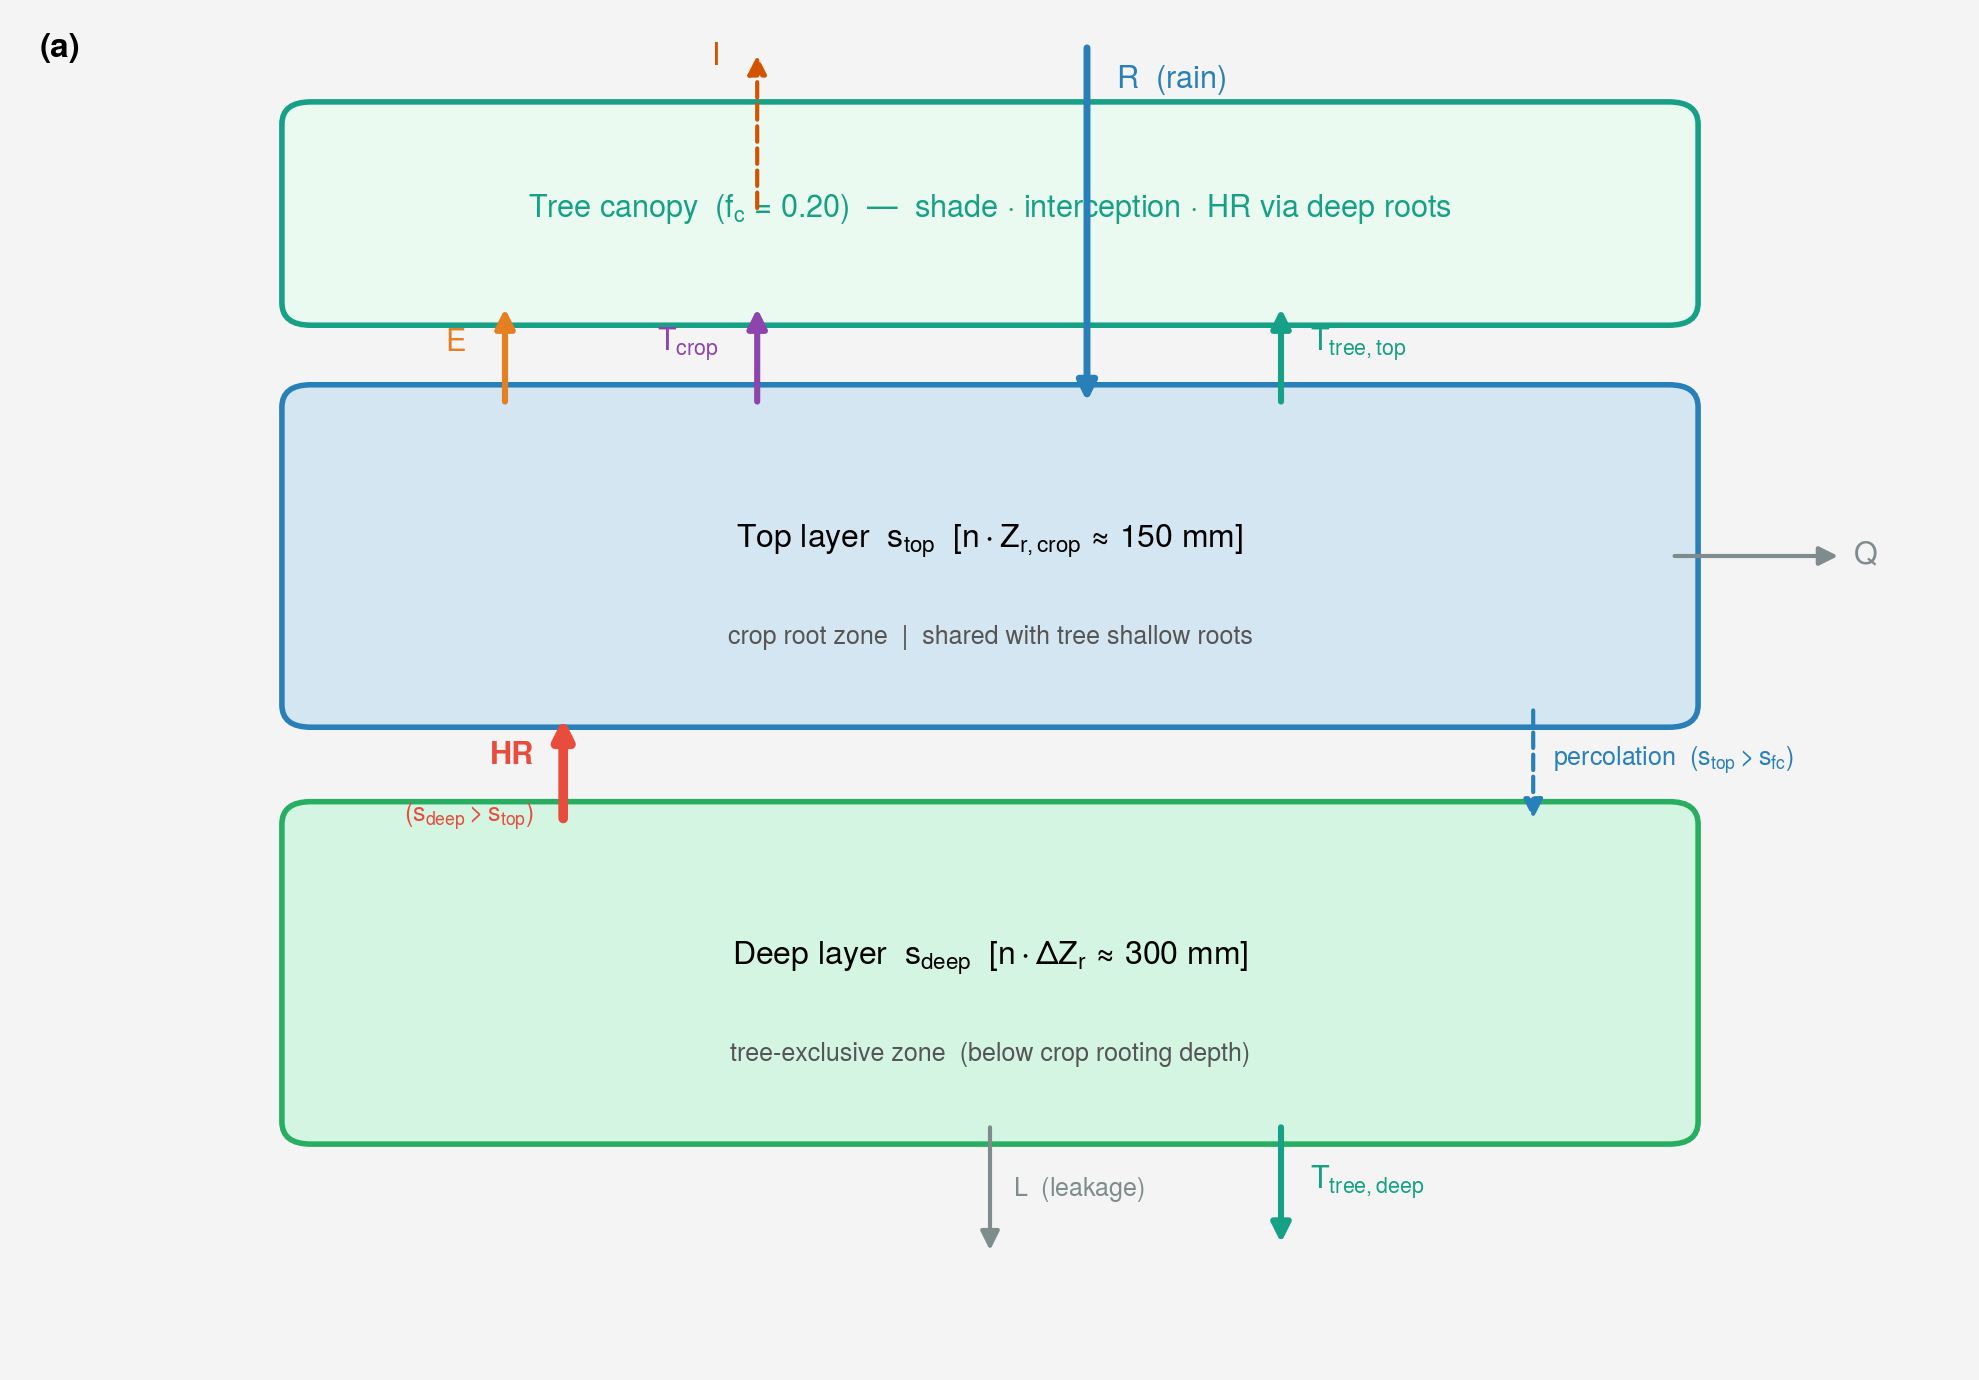

In [23]:

# ── Figure 1: Two-layer model schematic ─────────────────────────────────────
import os; os.makedirs("output", exist_ok=True)
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10); ax.set_ylim(0, 9); ax.axis("off")

CW  = "#2980b9"   # water / rain
CE  = "#e67e22"   # soil evaporation
CI  = "#d35400"   # canopy interception — distinct color + dashed to separate from E
CT  = "#8e44ad"   # crop transpiration
CTR = "#16a085"   # tree transpiration / canopy
CHR = "#e74c3c"   # hydraulic redistribution
CG  = "#7f8c8d"   # runoff / leakage
FS  = 11          # primary flux label size
FSS = 9           # secondary / condition annotation size

def _box(x, y, w, h, fc, ec, lw=2):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15",
                                facecolor=fc, edgecolor=ec, linewidth=lw))

def _arr(x0, y0, x1, y1, c, lw=2, linestyle="solid"):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=c, lw=lw,
                                linestyle=linestyle, mutation_scale=14))

# ── Boxes ────────────────────────────────────────────────────────────────────
_box(1.5, 7.1, 7, 1.2, "#eafaf1", CTR)
ax.text(5, 7.73, r"Tree canopy  ($f_c$ = 0.20)  —  shade · interception · HR via deep roots",
        ha="center", va="center", fontsize=FS, color=CTR)

_box(1.5, 4.4, 7, 2.0, "#d4e6f1", CW)
ax.text(5, 5.5,  r"Top layer  $s_{top}$  [$n \cdot Z_{r,crop}$ ≈ 150 mm]",
        ha="center", va="center", fontsize=FS + 0.5)
ax.text(5, 4.85, "crop root zone  |  shared with tree shallow roots",
        ha="center", va="center", fontsize=FSS, color="#555")

_box(1.5, 1.6, 7, 2.0, "#d5f5e3", "#27ae60")
ax.text(5, 2.7,  r"Deep layer  $s_{deep}$  [$n \cdot \Delta Z_r$ ≈ 300 mm]",
        ha="center", va="center", fontsize=FS + 0.5)
ax.text(5, 2.05, "tree-exclusive zone  (below crop rooting depth)",
        ha="center", va="center", fontsize=FSS, color="#555")

# ── Arrows ───────────────────────────────────────────────────────────────────
# Rain ↓ into top layer
_arr(5.5, 8.85, 5.5, 6.4, CW, lw=2.5)
ax.text(5.65, 8.6, r"$R$  (rain)", fontsize=FS, color=CW, va="center")

# Interception ↑ from canopy: dashed + distinct color from E
_arr(3.8, 7.7, 3.8, 8.8, CI, lw=1.5, linestyle="dashed")
ax.text(3.6, 8.7, r"$I$", fontsize=FS, color=CI, ha="right")

# Runoff Q → right of top (label kept inside axes with clip_on=False)
_arr(8.5, 5.4, 9.4, 5.4, CG, lw=1.5)
ax.text(9.45, 5.4, r"$Q$", fontsize=FS, color=CG, va="center", clip_on=False)

# E ↑ from top
_arr(2.5, 6.4, 2.5, 7.1, CE, lw=2.2)
ax.text(2.3, 6.78, r"$E$", fontsize=FS, color=CE, ha="right")

# T_crop ↑ from top
_arr(3.8, 6.4, 3.8, 7.1, CT, lw=2.2)
ax.text(3.6, 6.78, r"$T_{crop}$", fontsize=FS, color=CT, ha="right")

# T_tree_top ↑ from top
_arr(6.5, 6.4, 6.5, 7.1, CTR, lw=2.2)
ax.text(6.65, 6.78, r"$T_{tree,top}$", fontsize=FS, color=CTR)

# Percolation top → deep (dashed)
_arr(7.8, 4.4, 7.8, 3.6, CW, lw=1.5, linestyle="dashed")
ax.text(7.9, 4.0, r"percolation  ($s_{top} > s_{fc}$)", fontsize=FSS, color=CW)

# HR ↑ deep → top (bold red)
_arr(2.8, 3.6, 2.8, 4.35, CHR, lw=3.5)
ax.text(2.65, 4.0,  "HR", fontsize=FS, color=CHR, ha="right", fontweight="bold")
ax.text(2.65, 3.62, r"($s_{deep} > s_{top}$)", fontsize=FSS, color=CHR, ha="right")

# T_tree_deep ↓ from deep
_arr(6.5, 1.6, 6.5, 0.75, CTR, lw=2.2)
ax.text(6.65, 1.15, r"$T_{tree,deep}$", fontsize=FS, color=CTR)

# Leakage L ↓ from deep
_arr(5.0, 1.6, 5.0, 0.7, CG, lw=1.5)
ax.text(5.12, 1.1, r"$L$  (leakage)", fontsize=FSS, color=CG)

# Panel label
ax.text(0.01, 0.99, "(a)", transform=ax.transAxes,
        fontsize=12, fontweight="bold", va="top", ha="left")

plt.tight_layout()
plt.savefig("output/pres_fig1_schematic.png", dpi=300, bbox_inches="tight")
plt.savefig("output/pres_fig1_schematic.pdf", bbox_inches="tight")
plt.show()


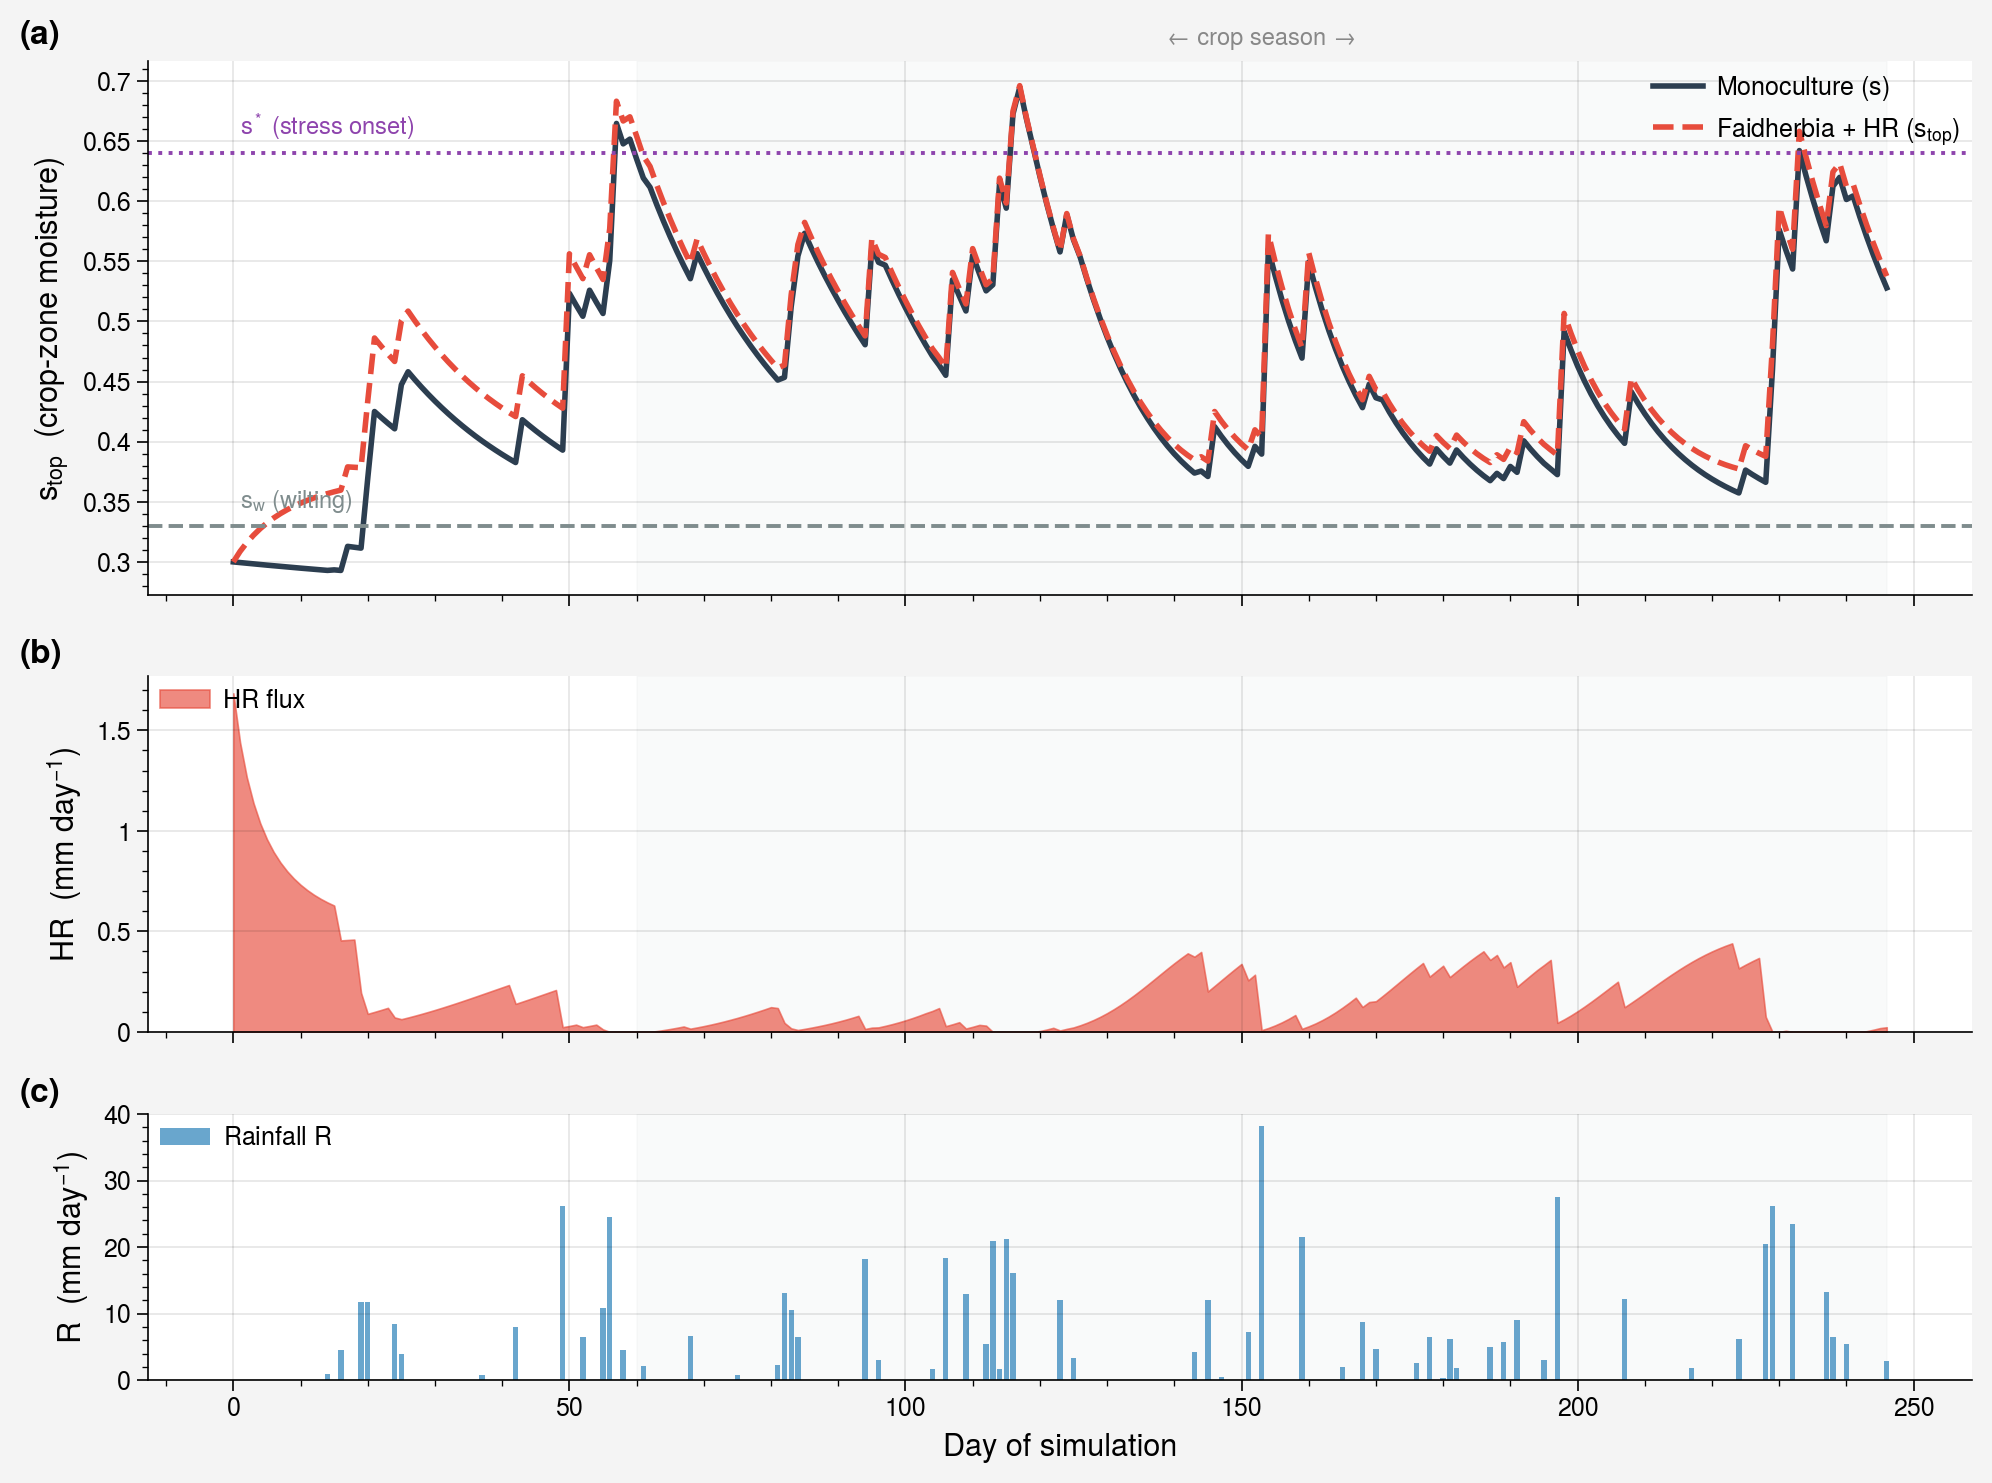

RF = 585 mm  |  HR (crop season) = 26.0 mm
Δ dynamic stress = -0.047  |  Δ yield = +203 kg/ha


In [24]:

# ── Figure 2: Single-season mechanism ─────────────────────────────────────
# Requires: out_m, out_t, crop_m (from single-season diagnostic cell f6f289b8)

fig, axes = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True,
                          gridspec_kw={"height_ratios": [3, 2, 1.5]})
days = np.arange(len(out_t))

# Shade the crop growing season (light gray — does not interact with red/blue palette)
in_season = out_t["dos"].values > 0
if in_season.any():
    x0_s, x1_s = days[in_season][0], days[in_season][-1]
    for _ax in axes:
        _ax.axvspan(x0_s, x1_s, alpha=0.08, color="#bdc3c7", zorder=0)

# Panel (a): crop-zone soil moisture
ax = axes[0]
ax.plot(days, out_m["s"].values,     lw=2, color="#2c3e50", label=r"Monoculture ($s$)")
ax.plot(days, out_t["s_top"].values, lw=2, color="#e74c3c", linestyle="--",
        label=r"Faidherbia + HR ($s_{top}$)")
ax.axhline(crop_m.s_star, color="#8e44ad", lw=1.4, linestyle=":",  alpha=1.0)
ax.axhline(crop_m.sw,     color="#7f8c8d", lw=1.4, linestyle="--", alpha=1.0)
ax.text(1, crop_m.s_star + 0.015, r"$s^*$ (stress onset)", fontsize=8.5, color="#8e44ad")
ax.text(1, crop_m.sw     + 0.015, r"$s_w$ (wilting)",      fontsize=8.5, color="#7f8c8d")
ax.set_ylabel(r"$s_\mathrm{top}$  (crop-zone moisture)", fontsize=11)
ax.legend(fontsize=9, loc="upper right")
if in_season.any():
    mid_s = (x0_s + x1_s) / 2.0
    yhi   = max(out_m["s"].values.max(), out_t["s_top"].values.max()) + 0.03
    ax.text(mid_s, yhi, "← crop season →", ha="center", va="bottom", fontsize=8.5, color="#888")
despine(ax)
pub_label(ax, "(a)", x=-0.07)

# Panel (b): HR flux (total in caption, not in legend)
ax = axes[1]
hr_crop = float(out_t["HR"].values[in_season].sum()) if in_season.any() else float(out_t["HR"].sum())
ax.fill_between(days, out_t["HR"].values, 0, color="#e74c3c", alpha=0.65, label="HR flux")
ax.set_ylabel(r"HR  (mm day$^{-1}$)", fontsize=11)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
despine(ax)
pub_label(ax, "(b)", x=-0.07)

# Panel (c): rainfall
ax = axes[2]
ax.bar(days, out_t["R"].values, width=0.8, color="#2980b9", alpha=0.7, label=r"Rainfall $R$")
ax.set_ylabel(r"$R$  (mm day$^{-1}$)", fontsize=11)
ax.set_xlabel("Day of simulation", fontsize=11)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
despine(ax)
pub_label(ax, "(c)", x=-0.07)

plt.tight_layout()
plt.savefig("output/pres_fig2_mechanism.png", dpi=300, bbox_inches="tight")
plt.savefig("output/pres_fig2_mechanism.pdf", bbox_inches="tight")
plt.show()

_, d_m2, y_m2, rf2 = season_metrics(crop_m, out_m, 180)
_, d_t2, y_t2, _   = season_metrics(crop_t, out_t, 180)
print(f"RF = {rf2:.0f} mm  |  HR (crop season) = {hr_crop:.1f} mm")
print(f"Δ dynamic stress = {d_t2 - d_m2:+.3f}  |  Δ yield = {y_t2 - y_m2:+.0f} kg/ha")


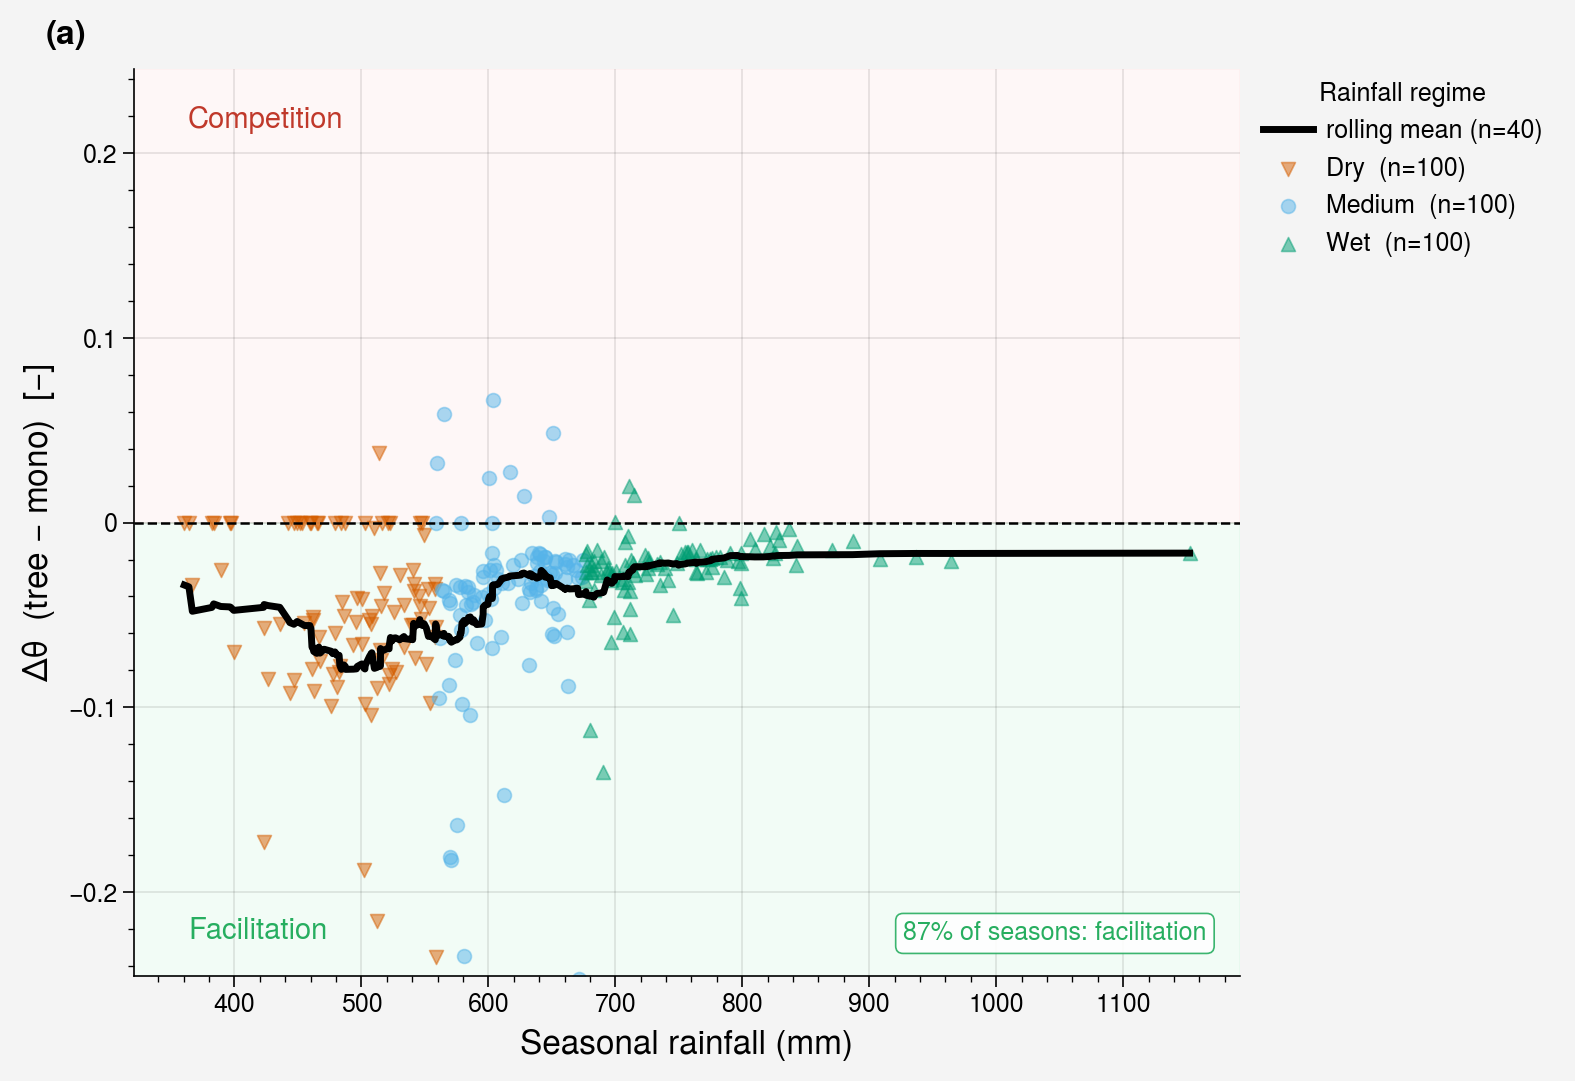

Dry       mean Δ=-0.064  facilitation=75%
Medium    mean Δ=-0.041  facilitation=89%
Wet       mean Δ=-0.025  facilitation=97%


In [25]:

# ── Figure 3: Competition→facilitation transition ──────────────────────────
# Requires: df_compare (from multi-season simulation cell f92563f5)

fig, ax = plt.subplots(figsize=(8, 5.5))

# Wong (2011) colorblind-safe palette for the three rainfall regimes
regime_colors = {"Dry": "#D55E00", "Medium": "#56B4E9", "Wet": "#009E73"}
regime_markers = {"Dry": "v", "Medium": "o", "Wet": "^"}

for regime, grp in df_compare.groupby("regime", observed=False):
    ax.scatter(grp["RF"].values, grp["delta_stress"].values,
               color=regime_colors[regime], marker=regime_markers[regime],
               alpha=0.5, s=25, label=f"{regime}  (n={len(grp)})", zorder=2)

# Smoother: LOWESS preferred; falls back to rolling mean if statsmodels unavailable
_df_s = df_compare.sort_values("RF").reset_index(drop=True)
try:
    from statsmodels.nonparametric.lowess import lowess as _sm_lowess
    _yx = _sm_lowess(_df_s["delta_stress"].values, _df_s["RF"].values,
                     frac=0.25, return_sorted=True)
    ax.plot(_yx[:, 0], _yx[:, 1], color="black", lw=2.5, zorder=3, label="LOWESS smoother")
except ImportError:
    _sm_vals = _df_s["delta_stress"].rolling(40, center=True, min_periods=10).mean()
    ax.plot(_df_s["RF"].values, _sm_vals.values, color="black", lw=2.5, zorder=3,
            label="rolling mean (n=40)")

ax.axhline(0, color="k", lw=0.9, linestyle="--")

ylim_val = max(abs(df_compare["delta_stress"].quantile(0.97)),
               abs(df_compare["delta_stress"].quantile(0.03))) * 1.3
ax.set_ylim(-ylim_val, ylim_val)
ax.axhspan(0,         ylim_val, alpha=0.04, color="#e74c3c", zorder=0)
ax.axhspan(-ylim_val, 0,        alpha=0.06, color="#2ecc71", zorder=0)

rf_lo = df_compare["RF"].min()
ax.text(rf_lo + 3,  ylim_val * 0.87, "Competition",  fontsize=10.5, color="#c0392b")
ax.text(rf_lo + 3, -ylim_val * 0.87, "Facilitation", fontsize=10.5, color="#27ae60", va="top")

fac_frac = (df_compare["delta_stress"] < 0).mean()
ax.text(0.97, 0.04, f"{fac_frac:.0%} of seasons: facilitation",
        transform=ax.transAxes, ha="right", fontsize=9, color="#27ae60",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#27ae60", alpha=0.9))

ax.set_xlabel("Seasonal rainfall (mm)", fontsize=12)
ax.set_ylabel(r"$\Delta\theta$  (tree $-$ mono)  [$-$]", fontsize=12)
despine(ax)
ax.legend(title="Rainfall regime", fontsize=9, title_fontsize=9,
          bbox_to_anchor=(1.01, 1), loc="upper left")
pub_label(ax, "(a)")

plt.tight_layout()
plt.savefig("output/pres_fig3_transition.png", dpi=300, bbox_inches="tight")
plt.savefig("output/pres_fig3_transition.pdf", bbox_inches="tight")
plt.show()

for _regime, _grp in df_compare.groupby("regime", observed=False):
    _mn  = _grp["delta_stress"].mean()
    _pct = (_grp["delta_stress"] < 0).mean()
    print(f"{_regime:8s}  mean Δ={_mn:+.3f}  facilitation={_pct:.0%}")


Deep roots only (no shade, no HR): Δ = +8.8  (COMPETITIVE — check deep-first allocation)


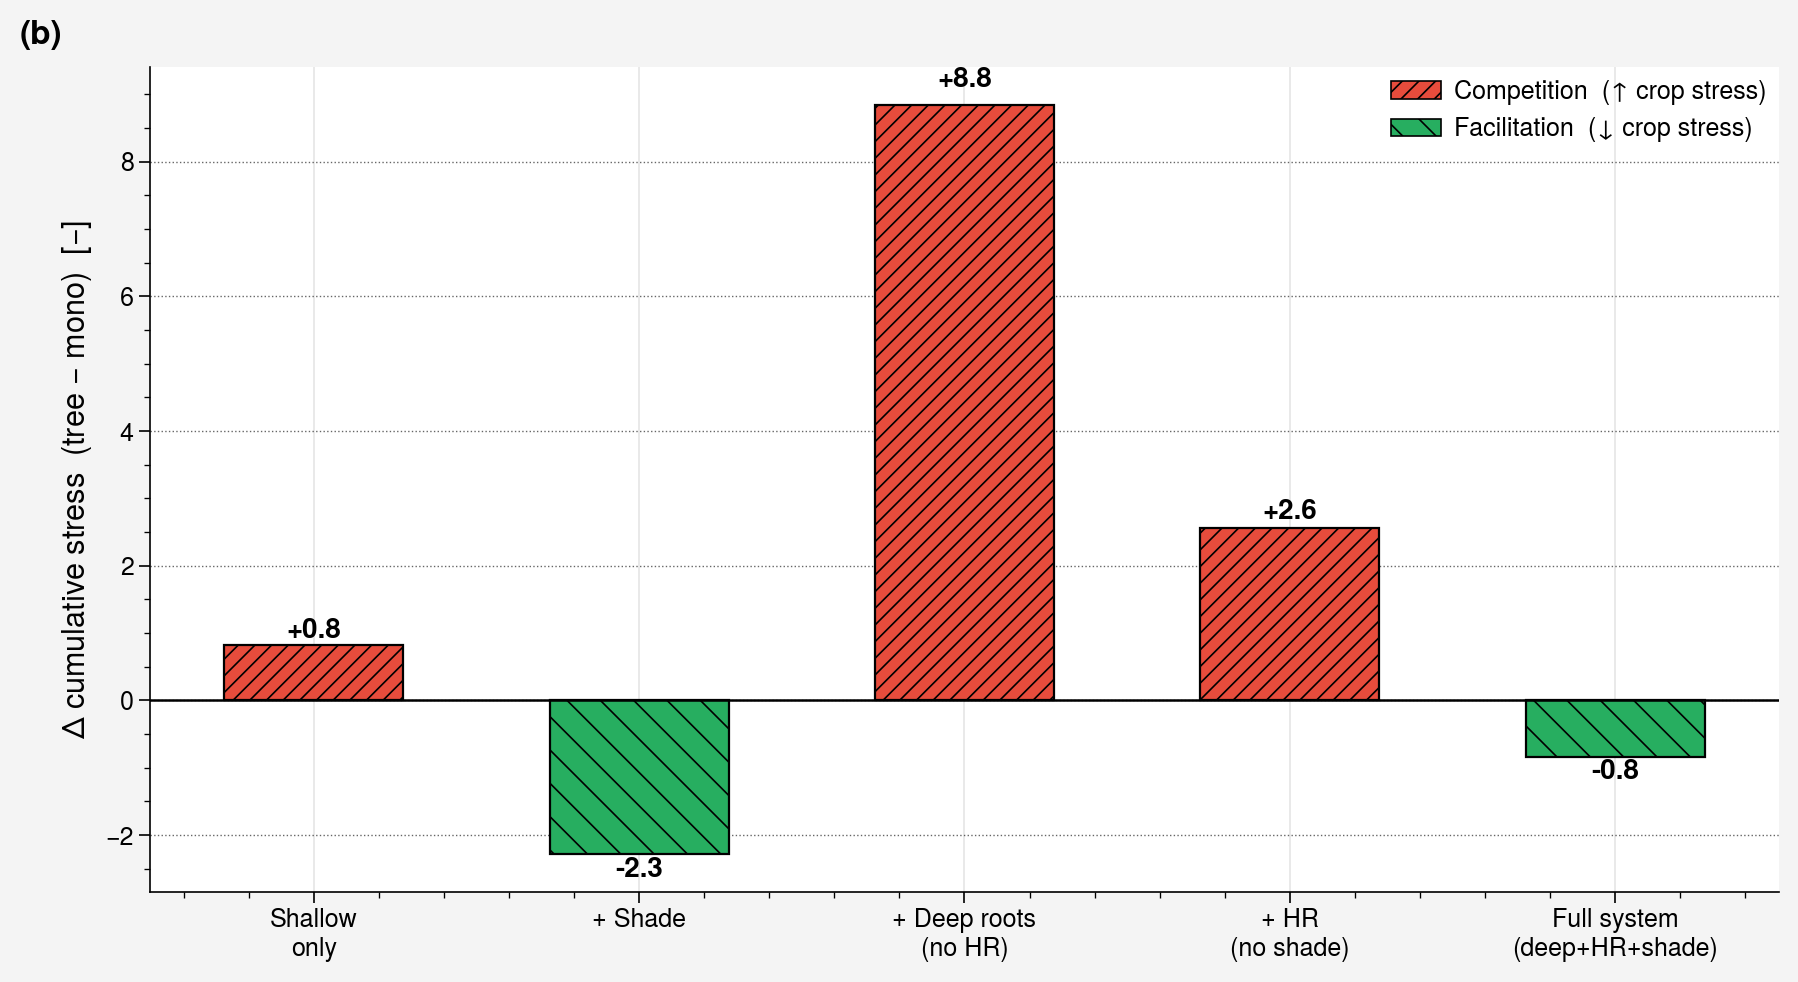


Monoculture baseline cumulative stress: 77.3
  Shallow only                         Δ = +0.8
  + Shade                              Δ = -2.3
  + Deep roots (no HR)                 Δ = +8.8
  + HR (no shade)                      Δ = +2.6
  Full system (deep+HR+shade)          Δ = -0.8


In [26]:

# ── Figure 4: Mechanism attribution (factorial) ────────────────────────────
# Evergreen phenology: all mechanisms active during crop season — cleanest decomposition.

np.random.seed(42)
_clim4 = Climate()
_tp_eg = dict(Zr=1500, T_MAX=4.0, sw_MPa=-2.0, s_star_MPa=-0.1,
              kc=1.0, canopy_cover=0.2, leaf_fraction=1.0)

def _fact_run(deep, shade, hr):
    _s = Soil("loam"); _c = Crop(soil=_s); _c.lgp = 180
    _t = Tree(soil=_s, **_tp_eg)
    _m = TreeCropModel(soil=_s, crop=_c, tree=_t, climate=_clim4)
    _m.run(deep_roots=deep, shade_on=shade, hr_on=hr)
    return _m.output()["stress"].sum()

# Monoculture baseline
_s0 = Soil("loam"); _c0 = Crop(soil=_s0); _c0.lgp = 180
_m0 = CropModel(soil=_s0, crop=_c0, climate=_clim4); _m0.run()
_base = _m0.output()["stress"].sum()

# Diagnostic: verify deep-roots-only sign (should be negative = facilitative,
# because deep-first allocation moves tree demand away from the crop zone)
_deep_only_delta = _fact_run(True, False, False) - _base
print(f"Deep roots only (no shade, no HR): Δ = {_deep_only_delta:+.1f}  "
      f"({'facilitative ✓' if _deep_only_delta < 0 else 'COMPETITIVE — check deep-first allocation'})")

scenarios = [
    ("Shallow\nonly",                _fact_run(False, False, False)),
    ("+ Shade",                      _fact_run(False, True,  False)),
    ("+ Deep roots\n(no HR)",        _fact_run(True,  False, False)),
    ("+ HR\n(no shade)",             _fact_run(True,  False, True)),
    ("Full system\n(deep+HR+shade)", _fact_run(True,  True,  True)),
]
labels4, stresses4 = zip(*scenarios)
deltas4    = [s - _base for s in stresses4]
bar_colors = ["#e74c3c" if d > 0 else "#27ae60" for d in deltas4]
bar_hatch  = ["////" if d > 0 else "\\\\" for d in deltas4]

fig, ax = plt.subplots(figsize=(9, 5))
from matplotlib.patches import Patch

bars = ax.bar(labels4, deltas4, color=bar_colors, hatch=bar_hatch,
              edgecolor="black", lw=0.8, zorder=2, width=0.55)
ax.axhline(0, color="k", lw=0.9)
ax.yaxis.grid(True, linestyle=":", linewidth=0.5, alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.set_ylabel(r"$\Delta$ cumulative stress  (tree $-$ mono)  [$-$]", fontsize=11)
despine(ax)

# Bar annotations — robust offset handles near-zero bars
ax_range = ax.get_ylim()[1] - ax.get_ylim()[0] if ax.get_ylim()[1] != ax.get_ylim()[0] else 40
for bar, d in zip(bars, deltas4):
    offset = 0.02 * max(abs(d), 1.0) * np.sign(d) if abs(d) > 0.5 else 0.02 * max(abs(min(deltas4)), abs(max(deltas4)))
    va = "bottom" if d >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width() / 2, d + offset, f"{d:+.1f}",
            ha="center", va=va, fontsize=10, fontweight="bold")

ax.legend(handles=[
    Patch(facecolor="#e74c3c", hatch="////", edgecolor="black", label="Competition  (↑ crop stress)"),
    Patch(facecolor="#27ae60", hatch="\\\\", edgecolor="black", label="Facilitation  (↓ crop stress)"),
], fontsize=9, loc="upper right")
pub_label(ax, "(b)")

plt.tight_layout()
plt.savefig("output/pres_fig4_factorial.png", dpi=300, bbox_inches="tight")
plt.savefig("output/pres_fig4_factorial.pdf", bbox_inches="tight")
plt.show()

print(f"\nMonoculture baseline cumulative stress: {_base:.1f}")
for lbl, d in zip(labels4, deltas4):
    print(f"  {lbl.replace(chr(10), ' '):35s}  Δ = {d:+.1f}")


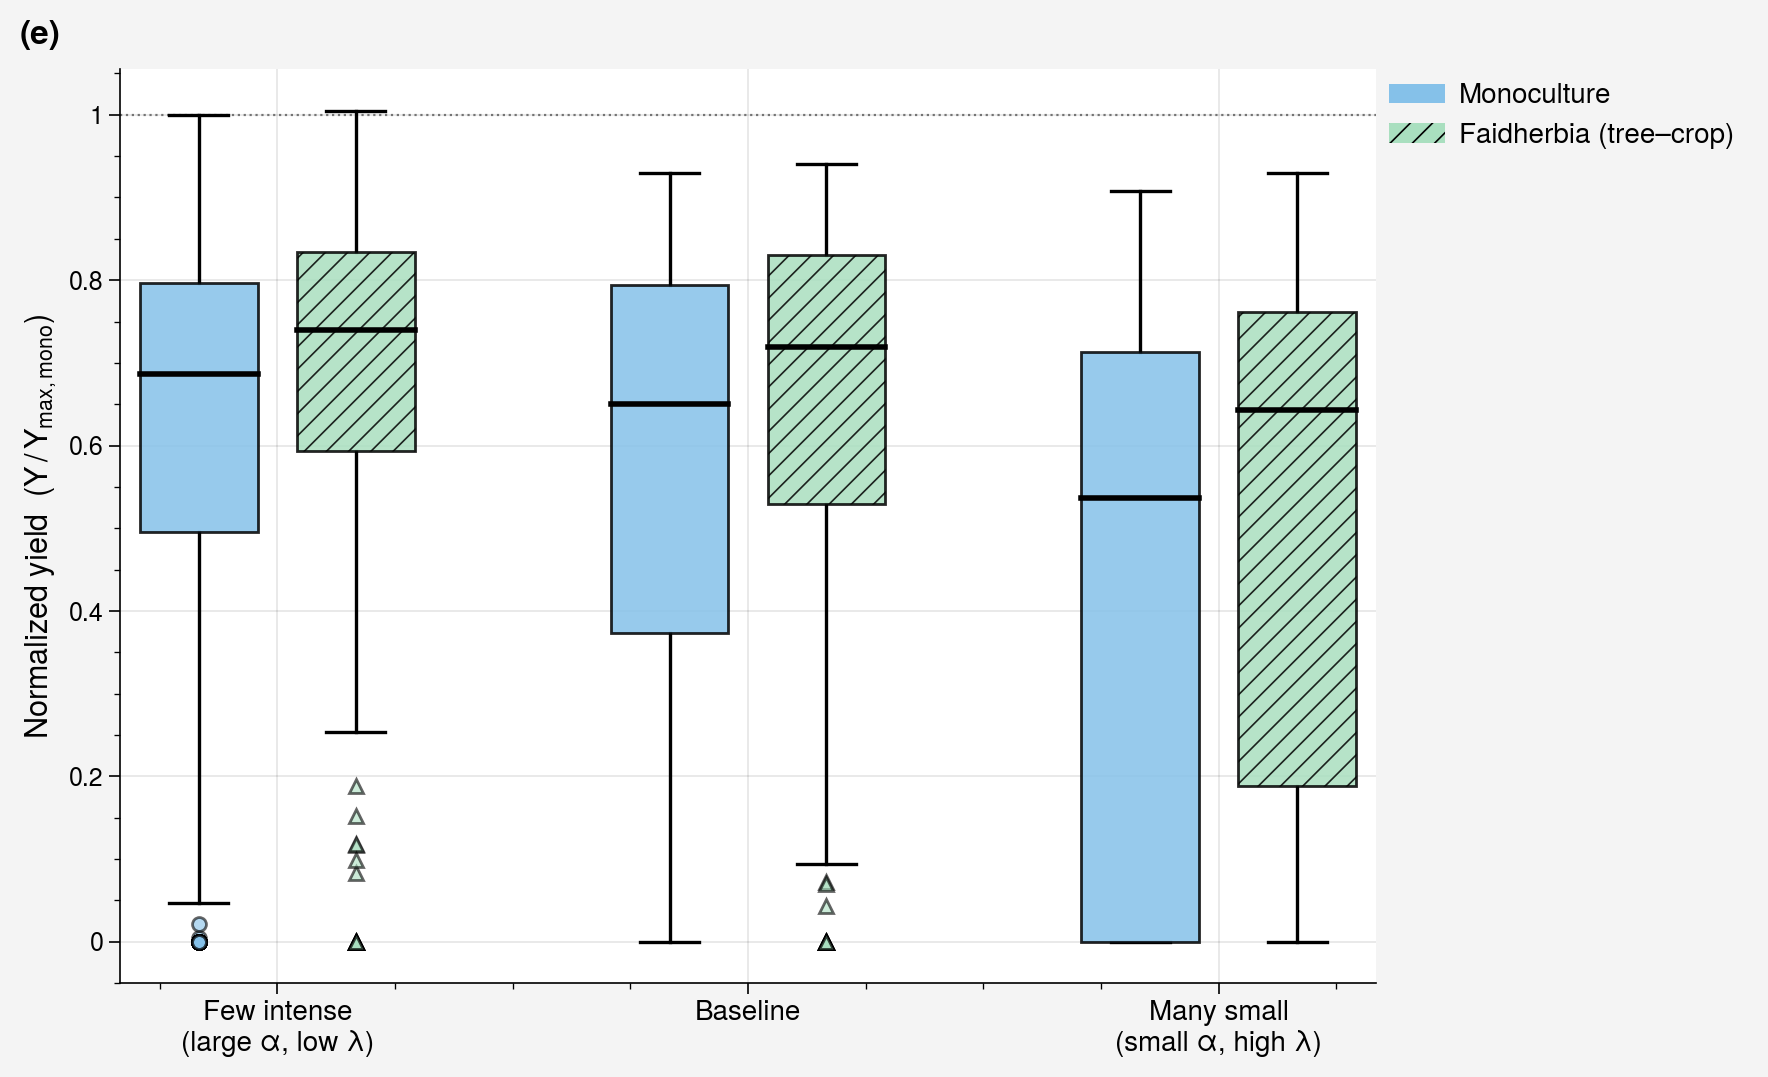

few_intense      mono=0.686  tree=0.740  Δ=+0.054
baseline         mono=0.651  tree=0.719  Δ=+0.069
many_small       mono=0.536  tree=0.643  Δ=+0.106


In [27]:

# ── Figure 5: Yield by rainfall regime ─────────────────────────────────────
_dm5 = df[df.System == "Mono"].copy()
_dt5 = df[df.System == "TreeCrop"].copy()
_ymax5 = _dm5["Yield"].max()
_dm5["Yn"] = _dm5["Yield"] / _ymax5
_dt5["Yn"] = _dt5["Yield"] / _ymax5

regime_order  = ["few_intense", "baseline", "many_small"]
regime_labels = ["Few intense\n(large α, low λ)", "Baseline",
                 "Many small\n(small α, high λ)"]

fig, ax = plt.subplots(figsize=(9, 5.5))
pos_m = [1, 4, 7]
pos_t = [2, 5, 8]

bp_kw_m = dict(widths=0.75, patch_artist=True,
               boxprops=dict(facecolor="#85c1e9", alpha=0.85),
               medianprops=dict(color="black", lw=2),
               whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
               flierprops=dict(marker="o", markersize=5, alpha=0.6, markerfacecolor="#85c1e9"))
bp_kw_t = dict(widths=0.75, patch_artist=True,
               # hatch added for grayscale / colorblind safety
               boxprops=dict(facecolor="#a9dfbf", alpha=0.85, hatch="///"),
               medianprops=dict(color="black", lw=2),
               whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
               flierprops=dict(marker="^", markersize=5, alpha=0.6, markerfacecolor="#a9dfbf"))

for i, regime in enumerate(regime_order):
    ax.boxplot(_dm5[_dm5.Regime == regime]["Yn"].dropna(), positions=[pos_m[i]], **bp_kw_m)
    ax.boxplot(_dt5[_dt5.Regime == regime]["Yn"].dropna(), positions=[pos_t[i]], **bp_kw_t)

ax.set_xticks([1.5, 4.5, 7.5])
ax.set_xticklabels(regime_labels, fontsize=10)
ax.set_ylabel(r"Normalized yield  ($Y \,/\, Y_\mathrm{max,mono}$)", fontsize=11)
ax.axhline(1.0, color="k", lw=0.8, linestyle=":", alpha=0.5)
despine(ax)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#85c1e9",               label="Monoculture"),
    Patch(facecolor="#a9dfbf", hatch="///",  label="Faidherbia (tree–crop)"),
], fontsize=10, bbox_to_anchor=(1.0, 1.0), loc="upper left")
pub_label(ax, "(e)")

plt.tight_layout()
plt.savefig("output/pres_fig5_yield_regime.png", dpi=300, bbox_inches="tight")
plt.savefig("output/pres_fig5_yield_regime.pdf", bbox_inches="tight")
plt.show()

for regime, label in zip(regime_order, regime_labels):
    med_m = _dm5[_dm5.Regime == regime]["Yn"].median()
    med_t = _dt5[_dt5.Regime == regime]["Yn"].median()
    print(f"{regime:15s}  mono={med_m:.3f}  tree={med_t:.3f}  Δ={med_t - med_m:+.3f}")


## Cross-species trait analysis

Three archetypes with contrasting functional traits. The goal: Faidherbia's reverse phenology + deep roots should *emerge* as the explanation for why it's uniquely facilitative — not be assumed.

| Archetype | Phenology | Zr (mm) | canopy_cover | Expected outcome |
|-----------|-----------|---------|--------------|-----------------|
| Faidherbia | reverse | 1500 | 0.2 | facilitation |
| Evergreen deep | evergreen | 1500 | 0.2 | mixed |
| Evergreen shallow | evergreen | 600 | 0.3 | competition |

In [28]:
ARCHETYPES = {
    "Faidherbia":        dict(Zr=1500, T_MAX=1.0, sw_MPa=-2.0, s_star_MPa=-0.1,
                              kc=1.0, canopy_cover=0.2, leaf_fraction=0.0),
    "Evergreen deep":    dict(Zr=1500, T_MAX=4.0, sw_MPa=-2.0, s_star_MPa=-0.1,
                              kc=1.0, canopy_cover=0.2, leaf_fraction=1.0),
    "Evergreen shallow": dict(Zr=600,  T_MAX=4.0, sw_MPa=-2.0, s_star_MPa=-0.1,
                              kc=1.0, canopy_cover=0.3, leaf_fraction=1.0),
}

_REGIME_SCALES = {
    "few_intense": dict(alpha_scale=1.5,  lambda_scale=0.67),
    "baseline":    dict(alpha_scale=1.0,  lambda_scale=1.0),
    "many_small":  dict(alpha_scale=0.67, lambda_scale=1.5),
}


def simulate_archetype_regimes(tree_params, n_sims=300, seed=42, lgp=180, texture="loam"):
    """
    Run n_sims seasons × 3 rainfall regimes for one tree archetype.
    Paired seasons: same climate object used for both mono and tree-crop.
    Returns DataFrame with columns:
        Regime, RF, Stress_mono, Stress_tree, Yield_mono, Yield_tree,
        delta_stress, delta_yield_kgha
    """
    rng = np.random.default_rng(seed)
    _default = Climate()
    sf = _tree_sf(tree_params)
    rows = []

    for regime, scales in _REGIME_SCALES.items():
        for _ in range(n_sims):
            np.random.seed(rng.integers(0, 2**32 - 1, dtype=np.uint32).item())
            climate = Climate(
                alpha_r=[a * scales["alpha_scale"] for a in _default.alpha_r],
                lambda_r=[l * scales["lambda_scale"] for l in _default.lambda_r],
                ET_max=_default.ET_max,
            )

            crop_m, out_m = run_one_season(CropModel, Soil, Crop, climate,
                                           texture=texture, lgp=lgp)
            _, d_m, y_m, rf = season_metrics(crop_m, out_m, lgp)

            crop_t, out_t = run_one_season(TreeCropModel, Soil, Crop, climate,
                                           texture=texture, lgp=lgp,
                                           tree_params=tree_params)
            _, d_t, y_t, _ = season_metrics(crop_t, out_t, lgp, sf=sf)

            rows.append(dict(
                Regime=regime, RF=rf,
                Stress_mono=d_m, Stress_tree=d_t,
                Yield_mono=y_m,  Yield_tree=y_t,
                delta_stress=d_t - d_m,
                delta_yield_kgha=y_t - y_m,
            ))

    return pd.DataFrame(rows)


In [29]:
# Run all 3 archetypes — 300 seasons × 3 regimes each = 900 season-pairs per archetype
arch_results = {}
for name, params in ARCHETYPES.items():
    print(f"Running {name}...")
    arch_results[name] = simulate_archetype_regimes(params, n_sims=300, seed=42)
    fac = (arch_results[name]["delta_stress"] < 0).mean()
    dy  = arch_results[name]["delta_yield_kgha"].mean()
    print(f"  facilitative: {fac:.0%}   mean Δ yield: {dy:+.0f} kg/ha")

df_cross = pd.concat(
    [df.assign(Archetype=name) for name, df in arch_results.items()],
    ignore_index=True,
)

Running Faidherbia...


  facilitative: 84%   mean Δ yield: +209 kg/ha
Running Evergreen deep...


  facilitative: 44%   mean Δ yield: +0 kg/ha
Running Evergreen shallow...


  facilitative: 3%   mean Δ yield: -652 kg/ha


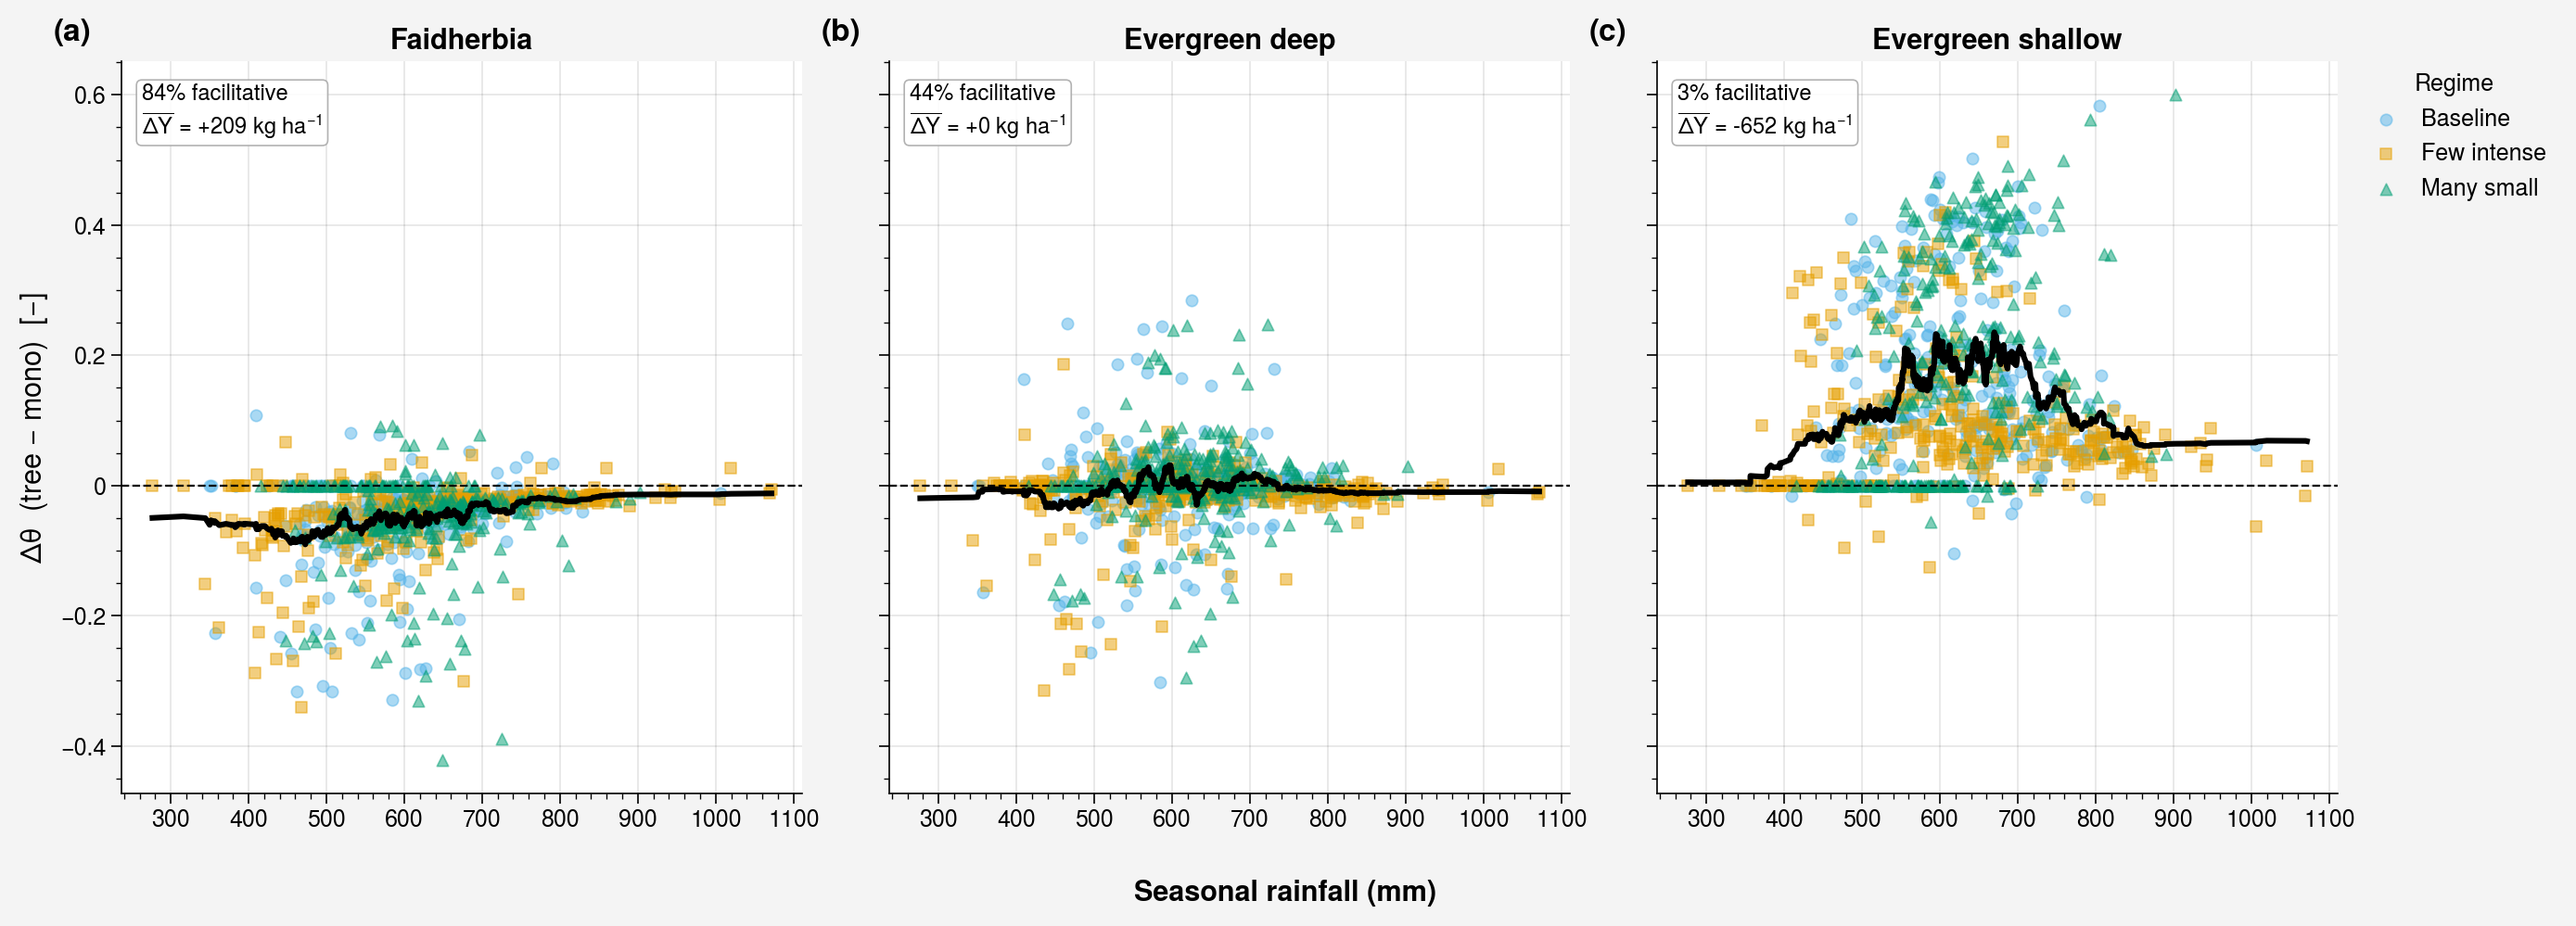

In [30]:
# Figure: Δ stress vs. RF — one panel per archetype, colored by regime
# Wong (2011) colorblind-safe palette + distinct markers per regime
_regime_colors  = {"few_intense": "#E69F00", "baseline": "#56B4E9", "many_small": "#009E73"}
_regime_markers = {"few_intense": "s",       "baseline": "o",       "many_small": "^"}
_regime_labels  = {"few_intense": "Few intense", "baseline": "Baseline", "many_small": "Many small"}

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True, sharex=True)

for ax, (name, df) in zip(axes, arch_results.items()):
    for regime, grp in df.groupby("Regime"):
        ax.scatter(grp["RF"].values, grp["delta_stress"].values,
                   color=_regime_colors[regime], marker=_regime_markers[regime],
                   alpha=0.5, s=20, label=_regime_labels[regime], zorder=2)

    # Running mean across all regimes (RF-sorted)
    _s  = df.sort_values("RF").reset_index(drop=True)
    _sm = _s["delta_stress"].rolling(40, center=True, min_periods=10).mean()
    ax.plot(_s["RF"].values, _sm.values, color="black", lw=2.2, zorder=3)
    ax.axhline(0, color="k", lw=0.8, linestyle="--")

    fac_frac = (df["delta_stress"] < 0).mean()
    mean_dy  = df["delta_yield_kgha"].mean()
    # In-panel annotation (cleaner than set_title for multi-panel figures)
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.text(0.03, 0.97,
            f"{fac_frac:.0%} facilitative\n" + r"$\overline{\Delta Y}$ = " + f"{mean_dy:+.0f} kg ha$^{{-1}}$",
            transform=ax.transAxes, ha="left", va="top", fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#aaa", alpha=0.9))
    despine(ax)

axes[0].set_ylabel(r"$\Delta\theta$  (tree $-$ mono)  [$-$]", fontsize=11)

# Single shared x-label
fig.supxlabel("Seasonal rainfall (mm)", fontsize=11, y=0.01)

# Panel labels
for i, ax in enumerate(axes):
    pub_label(ax, f"({'abc'[i]})", x=-0.10)

# Deduplicated legend outside the figure (rightmost panel)
_seen = {}
for h, l in zip(*axes[-1].get_legend_handles_labels()):
    _seen.setdefault(l, h)
axes[-1].legend(_seen.values(), _seen.keys(), fontsize=9, title="Regime",
                title_fontsize=9, bbox_to_anchor=(1.02, 1.0), loc="upper left")

plt.tight_layout()
plt.savefig("output/cross_species_scatter.png", dpi=300, bbox_inches="tight")
plt.savefig("output/cross_species_scatter.pdf", bbox_inches="tight")
plt.show()

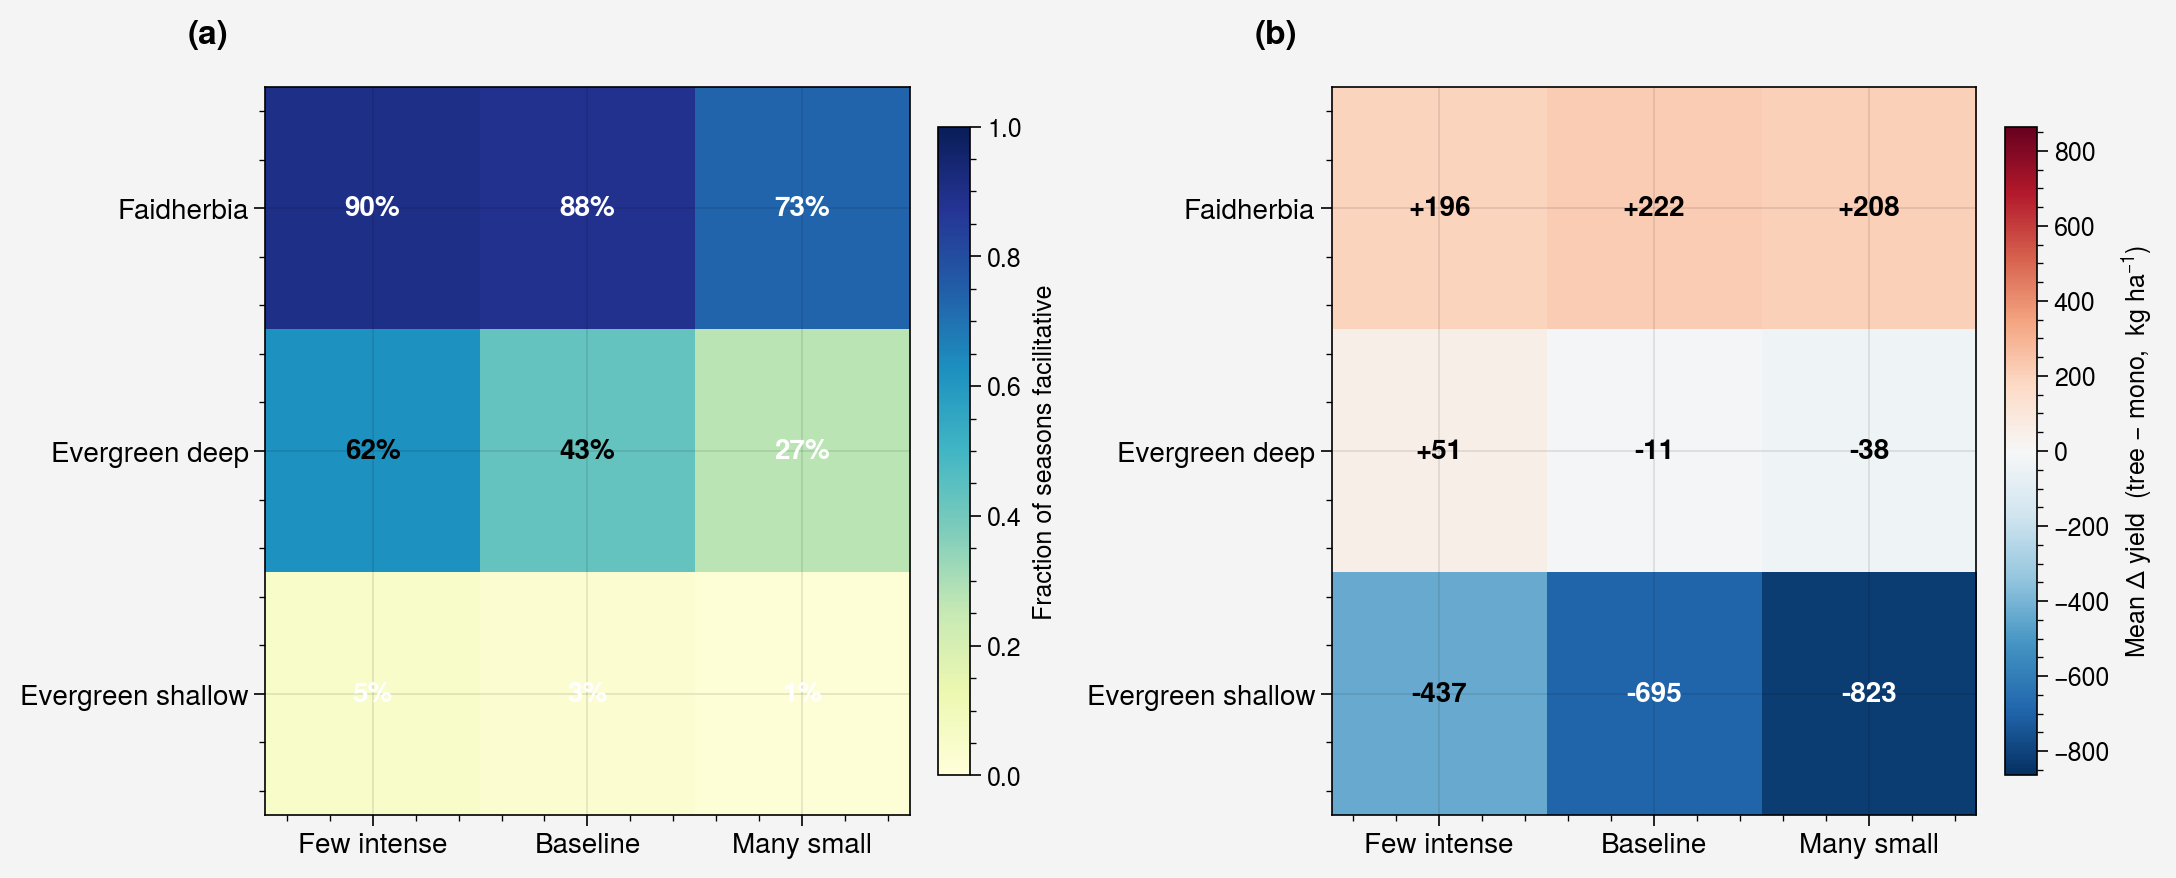

                         few_intense     baseline   many_small    OVERALL
--------------------------------------------------------------------------
Faidherbia                90% / +196   88% / +222   73% / +208   84% / +209 kg/ha
Evergreen deep             62% / +51    43% / -11    27% / -38   44% / +0 kg/ha
Evergreen shallow          5% / -437    3% / -695    1% / -823    3% / -652 kg/ha

(format: facilitation% / mean Δ yield kg/ha)


In [31]:
# Heatmap: facilitation fraction and mean Δ yield (kg/ha) by archetype × regime
_arch_order   = list(ARCHETYPES.keys())
_regime_order = ["few_intense", "baseline", "many_small"]
_xlabels      = ["Few intense", "Baseline", "Many small"]

fac_mat   = np.zeros((len(_arch_order), len(_regime_order)))
yield_mat = np.zeros((len(_arch_order), len(_regime_order)))

for i, arch in enumerate(_arch_order):
    df = arch_results[arch]
    for j, regime in enumerate(_regime_order):
        grp = df[df["Regime"] == regime]
        fac_mat[i, j]   = (grp["delta_stress"] < 0).mean()
        yield_mat[i, j] = grp["delta_yield_kgha"].mean()   # kg/ha — avoids pct blow-up

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Panel (a): facilitation fraction — YlGnBu is colorblind-safe and grayscale-friendly
im0 = axes[0].imshow(fac_mat, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
axes[0].set_xticks(range(len(_regime_order))); axes[0].set_xticklabels(_xlabels, fontsize=10)
axes[0].set_yticks(range(len(_arch_order)));   axes[0].set_yticklabels(_arch_order, fontsize=10)
cbar0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label("Fraction of seasons facilitative", fontsize=9)
for i in range(len(_arch_order)):
    for j in range(len(_regime_order)):
        c = "white" if fac_mat[i, j] > 0.65 or fac_mat[i, j] < 0.35 else "black"
        axes[0].text(j, i, f"{fac_mat[i, j]:.0%}", ha="center", va="center",
                     fontsize=10, fontweight="bold", color=c)

# Panel (b): mean Δ yield — RdBu_r is colorblind-safe diverging (blue=facilitation, red=competition)
_vmax = max(abs(yield_mat.min()), abs(yield_mat.max())) * 1.05
im1 = axes[1].imshow(yield_mat, cmap="RdBu_r", vmin=-_vmax, vmax=_vmax, aspect="auto")
axes[1].set_xticks(range(len(_regime_order))); axes[1].set_xticklabels(_xlabels, fontsize=10)
axes[1].set_yticks(range(len(_arch_order)));   axes[1].set_yticklabels(_arch_order, fontsize=10)
cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label(r"Mean $\Delta$ yield  (tree $-$ mono,  kg ha$^{-1}$)", fontsize=9)
for i in range(len(_arch_order)):
    for j in range(len(_regime_order)):
        c = "white" if abs(yield_mat[i, j]) > 0.55 * _vmax else "black"
        axes[1].text(j, i, f"{yield_mat[i, j]:+.0f}", ha="center", va="center",
                     fontsize=10, fontweight="bold", color=c)

pub_label(axes[0], "(a)", x=-0.12, y=1.05)
pub_label(axes[1], "(b)", x=-0.12, y=1.05)

plt.tight_layout()
plt.savefig("output/cross_species_heatmap.png", dpi=300, bbox_inches="tight")
plt.savefig("output/cross_species_heatmap.pdf", bbox_inches="tight")
plt.show()

# Summary table
print(f"{'':20s}  {'few_intense':>14} {'baseline':>12} {'many_small':>12}  {'OVERALL':>9}")
print("-" * 74)
for arch in _arch_order:
    df = arch_results[arch]
    by_regime = [
        f"{(df[df.Regime==r]['delta_stress']<0).mean():.0%} / {df[df.Regime==r]['delta_yield_kgha'].mean():+.0f}"
        for r in _regime_order
    ]
    overall_fac = f"{(df['delta_stress']<0).mean():.0%}"
    overall_dy  = f"{df['delta_yield_kgha'].mean():+.0f} kg/ha"
    print(f"{arch:20s}  {by_regime[0]:>14} {by_regime[1]:>12} {by_regime[2]:>12}  {overall_fac:>4} / {overall_dy}")
print("\n(format: facilitation% / mean Δ yield kg/ha)")